# 29_04 — Evaluación predictiva · BTCUSDT 5m · retorno intradía + volatilidad realizada · **barrido en $M$**

Paso **3b** del ciclo. Supone que `29_03_convergencia` dio veredicto OK **en
cada punto del barrido**; si las cadenas de un $M$ no convergieron, sus cifras
aquí no significan nada.

## Qué se reporta

- Predicción funcional a $h=1$ y su intervalo de credibilidad — se PERSISTEN, es lo que consume `29_05`
- **Bloque A** (MAE, RMSE, error máximo) sobre la ventana móvil
- **Bloque B** (Winkler, cobertura simultánea, cobertura puntual, MPIW) sobre la ventana móvil
- Muestra de predicciones: extractos regulares del test y las peores ventanas, con la curva anterior al lado
- Probabilidades posteriores de inclusión (PIP)
- Cuadro resumen: mínimo, máximo y promedio de cada métrica sobre la ventana
- Monitoreo univariado por componente FPCA
- **§10: evaluación puntual de los scores (coeficientes)** — banda de credibilidad de cada $\xi_k$, métricas de intervalo sobre ella, y dispersión $\hat\xi$ contra $\xi$

Todo el cálculo vive en `fit/` y todo el dibujo en `graphics/`: este notebook
sólo orquesta.



## 1. Imports, `[CONFIG]` y artefactos

In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

from model_psbp_fd.fit.convergencia_barrido import (
    cargar_artefactos, cargar_trazas, pip_punto,
)
from model_psbp_fd.fit.evaluacion_barrido import (
    METRICAS_A as _MA, METRICAS_B as _MB,
    cargar_representaciones, serie_origenes, predecir_barrido, guardar_bandas,
    tablas_ventana, apilar_tablas, verificar_relaciones_metricas,
    ganancias_por_ventana, tabla_ganadores_test, saltos_T0, peores_ventanas,
    resumen_metricas, resumen_barrido, monitoreo_scores, intervalos_scores,
)
from model_psbp_fd.graphics import (
    plot_ventana_movil, plot_extractos_curvas,
    plot_ganador_ventana, plot_scores_banda, plot_scores_dispersion,
)
from model_psbp_fd.utils import get_project_root, experiment_id, normalizar_lista_M
from model_psbp_fd.utils.rutas import ruta_barrido_M

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Identidad de la corrida: mismos valores que 29_01 §1.1. El ID es
# real_<serie>_v<NN>_m<NN>; las funciones de fit/ lo arman con (BASE_LIB, ESCENARIO_ID, None).
BASENAME, SERIE_ID, VENTANA_ID = "real", "btcusdt_vr", 1   # ventana 1: 2020-2026, 70/30 (29_01 §1.1)
M_FPCA_LIST = (1, 2, 3, 4)
DOMINIO      = "reales"
BASE_LIB     = f"{BASENAME}_{SERIE_ID}"
ESCENARIO_ID = f"v{VENTANA_ID:02d}"
REPLICA_ID   = None

# Propias de la evaluación. Las ventanas, el nivel y el objetivo se LEEN de
# eval_config.json (artefacto de 29_01): no se redeclaran aquí.
SALTAR_M_SIN_TRAZAS = True    # mirar el barrido mientras MATLAB va terminando
PESOS_TAU           = None    # cuadratura trapezoidal por defecto
METRICA_PEORES      = "rmse_f"   # cualquiera de las columnas de METRICAS_A / METRICAS_B
N_PEORES            = 5

# Predicción a h=1 (§3). S = (nsim - burn) x S_POR_ITER x n_cadenas draws por score;
# subirlos sólo reduce el error Monte Carlo de los cuantiles.
S_POR_ITER  = 1
S_FUNC      = 1000      # muestras funcionales tras adelgazar
BLOQUE_ORIG = 200       # orígenes por tramo al propagar a la curva (memoria; G = 288)
SEED_PRED   = 20260823
CADA        = 30        # un extracto de curva cada CADA períodos (§6)
CADA_BARRA  = 12        # un origen de cada CADA_BARRA lleva barra de IC (§10.3)

# §7: dispersión entre cadenas del PIP que se avisa.
SD_PIP_MAX = 0.15

# Las 10 métricas del marco teórico 02_02_03, en su orden. No se agregan otras.
METRICAS_A = [("1. MAE  (L^1)", "mae_f"), ("2. RMSE (L^2)", "rmse_f"),
              ("3. E_max promedio por curva", "linf_medio"),
              ("4. E_max peor de la ventana", "linf_max")]
METRICAS_B = [("5. MPIW", "mpiw"), ("6. PICP puntual", "picp"),
              ("7. PICPB curva completa", "picp_simultaneo"), ("8. Winkler", "winkler"),
              ("9. Winkler max promedio", "winkler_max_medio"),
              ("10. Winkler max peor ventana", "winkler_max_glob")]
assert METRICAS_A == _MA and METRICAS_B == _MB, "METRICAS_* difieren de fit.evaluacion_barrido."
METRICAS_A_COLS = [c for _, c in METRICAS_A]
METRICAS_B_COLS = [c for _, c in METRICAS_B]

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
EXPERIMENT_BASE = experiment_id(BASE_LIB, ESCENARIO_ID, REPLICA_ID)
PATH_BARRIDO    = ruta_barrido_M(BASE_LIB, ESCENARIO_ID, REPLICA_ID, dominio=DOMINIO,
                                 project_root=PROJECT_ROOT)

print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"barrido en M    : {list(M_FPCA_LIST)}")
print(f"salidas cruzadas: {PATH_BARRIDO}")

EXPERIMENT_BASE : real_btcusdt_vr_v01
barrido en M    : [1, 2, 3, 4]
salidas cruzadas: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_barrido_M


In [3]:
# EST[M]: estado de cada punto (cruza el contrato al cargar). DIS: diseño común.
EST, saltados = cargar_artefactos(BASE_LIB, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                                  PROJECT_ROOT, con_test=True, dominio=DOMINIO)
DIS = cargar_representaciones(EST)

T, T0, N_LAGS, NIVEL = DIS["T"], DIS["T0"], DIS["N_LAGS"], DIS["NIVEL"]
VENTANAS_W, W_REF    = DIS["VENTANAS_W"], DIS["W_REF"]
grilla, X_obs, X_suav = DIS["grilla"], DIS["X_obs"], DIS["X_suav"]

  M  comp  cadenas  covariables  seed_base
  1     1        2            8  41232
  2     2        2           15  41232
  3     3        2           22  41232
  4     4        2           29  41232

OK misma configuracion MCMC en todos los M: nsim/N/burn/cadenas = (2500, 30, 500, 2)
M=1  FPCA M=1 K=29  var. explicada=80.5891%  ·  curvas (2434, 288)
M=2  FPCA M=2 K=29  var. explicada=90.3925%  ·  curvas (2434, 288)
M=3  FPCA M=3 K=29  var. explicada=93.4950%  ·  curvas (2434, 288)
M=4  FPCA M=4 K=29  var. explicada=95.3619%  ·  curvas (2434, 288)

OK 4 puntos con el mismo diseno, objetivo, MCMC y simulacion.
T=2434 T0=1703 n_lags=7   ventanas w=[20, 30, 40]   referencia w=30   nivel=0.95


## 2. Trazas MCMC

Una lectura por punto del barrido. El `feature_names` del `.mat` se verifica
contra las columnas del dataset: con $M$ distintos el número de covariables
cambia, y un `.mat` del punto equivocado se detectaría aquí y no más adelante
como un resultado raro.

In [4]:
M_OK = cargar_trazas(EST, SALTAR_M_SIN_TRAZAS)     # los M efectivamente disponibles

OK M=1: 1 componente(s) x 2 cadena(s) · 2000 draws posteriores c/u -> 4000 por componente
OK M=2: 2 componente(s) x 2 cadena(s) · 2000 draws posteriores c/u -> 4000 por componente
OK M=3: 3 componente(s) x 2 cadena(s) · 2000 draws posteriores c/u -> 4000 por componente
OK M=4: 4 componente(s) x 2 cadena(s) · 2000 draws posteriores c/u -> 4000 por componente


## 3. Predicción a $h=1$ sobre la serie completa


In [5]:
ORIG = serie_origenes(DIS)
t_orig, n_orig, T0_orig, es_train = ORIG["t_orig"], ORIG["n_orig"], ORIG["T0_orig"], ORIG["es_train"]
X_obj_ev, X_obs_ev = ORIG["X_obj_ev"], ORIG["X_obs_ev"]

predecir_barrido(EST, M_OK, DIS, ORIG, S_POR_ITER, S_FUNC, BLOQUE_ORIG, SEED_PRED)

origenes evaluados: 2427  (train 1696 · test 731)
SC_draws de TODO el barrido: 388 MB en float32
M=1: S=4000 extracciones por score · funcionales 1000 (1 de cada 4) · SC_draws 39 MB
       MISE del TRUNCAMIENTO FPCA (test) = 0.000055   <- distancia del objetivo a su propia proyeccion en M
M=2: S=4000 extracciones por score · funcionales 1000 (1 de cada 4) · SC_draws 78 MB
       MISE del TRUNCAMIENTO FPCA (test) = 0.000024   <- distancia del objetivo a su propia proyeccion en M
M=3: S=4000 extracciones por score · funcionales 1000 (1 de cada 4) · SC_draws 116 MB
       MISE del TRUNCAMIENTO FPCA (test) = 0.000016   <- distancia del objetivo a su propia proyeccion en M
M=4: S=4000 extracciones por score · funcionales 1000 (1 de cada 4) · SC_draws 155 MB
       MISE del TRUNCAMIENTO FPCA (test) = 0.000011   <- distancia del objetivo a su propia proyeccion en M


### 3.1 Persistencia

La banda y la predicción puntual se guardan en `predict/` -no en `reports/`,
es un objeto de datos y no una salida de lectura- porque `29_05` las necesita
para calcular el Winkler del PSBPM-FD sobre su propia ventana móvil sin volver
a muestrear la predictiva completa.

In [6]:
guardar_bandas(EST, M_OK, DIS, ORIG)

[M=1] banda funcional -> banda_funcional_psbp.npz  (7.6 MB, (2427, 288))
[M=2] banda funcional -> banda_funcional_psbp.npz  (7.6 MB, (2427, 288))
[M=3] banda funcional -> banda_funcional_psbp.npz  (7.6 MB, (2427, 288))
[M=4] banda funcional -> banda_funcional_psbp.npz  (7.6 MB, (2427, 288))
Banda por CUANTILES de la predictiva muestral: no supone forma alguna.


## 4. Bloque A: error puntual sobre la ventana móvil

Las tres normas del MISMO error $e_t(\tau) = X_t(\tau) - \hat X_t(\tau)$:

| | qué estima | qué añade |
|---|---|---|
| **MAE** ($L^1$) | mediana condicional | robusta: un origen catastrófico no la mueve |
| **RMSE** ($L^2$) | media condicional | la que usa el PSBPM-FD y el resto del capítulo |
| **Error máximo** ($L^\infty$, promedio por curva) | peor caso | por curva, $\max_\tau \lvert e_t(\tau)\rvert$; sobre la ventana, el promedio de esos $w$ máximos |

Todo se calcula UNA vez por M en `tablas_fun` -la misma tabla que consume el
Bloque B de §5- y se dibuja aquí SOLO el Bloque A.

[ventana_movil_funcional[w=30]] inicio (2398 pasos)
  1/2398 ( 0.0%) t=0.0s eta=6.0s  t=22 [train] mise=0.0003405
  119/2398 ( 5.0%) t=0.0s eta=0.7s  t=140 [train] mise=0.0007488
  238/2398 ( 9.9%) t=0.1s eta=0.7s  t=259 [train] mise=0.0003073
  357/2398 (14.9%) t=0.1s eta=0.7s  t=378 [train] mise=0.001818
  476/2398 (19.8%) t=0.2s eta=0.6s  t=497 [train] mise=0.001769
  595/2398 (24.8%) t=0.2s eta=0.6s  t=616 [train] mise=0.0006653
  714/2398 (29.8%) t=0.2s eta=0.5s  t=735 [train] mise=0.0002333
  833/2398 (34.7%) t=0.3s eta=0.5s  t=854 [train] mise=0.0007126
  952/2398 (39.7%) t=0.3s eta=0.5s  t=973 [train] mise=0.0006258
  1071/2398 (44.7%) t=0.3s eta=0.4s  t=1092 [train] mise=8.85e-05
  1190/2398 (49.6%) t=0.4s eta=0.4s  t=1211 [train] mise=0.0002373
  1309/2398 (54.6%) t=0.4s eta=0.3s  t=1330 [train] mise=0.0001357
  1428/2398 (59.5%) t=0.4s eta=0.3s  t=1449 [train] mise=0.0002638
  1547/2398 (64.5%) t=0.5s eta=0.3s  t=1568 [train] mise=0.0003724
  1666/2398 (69.5%) t=0.5s eta=0.2

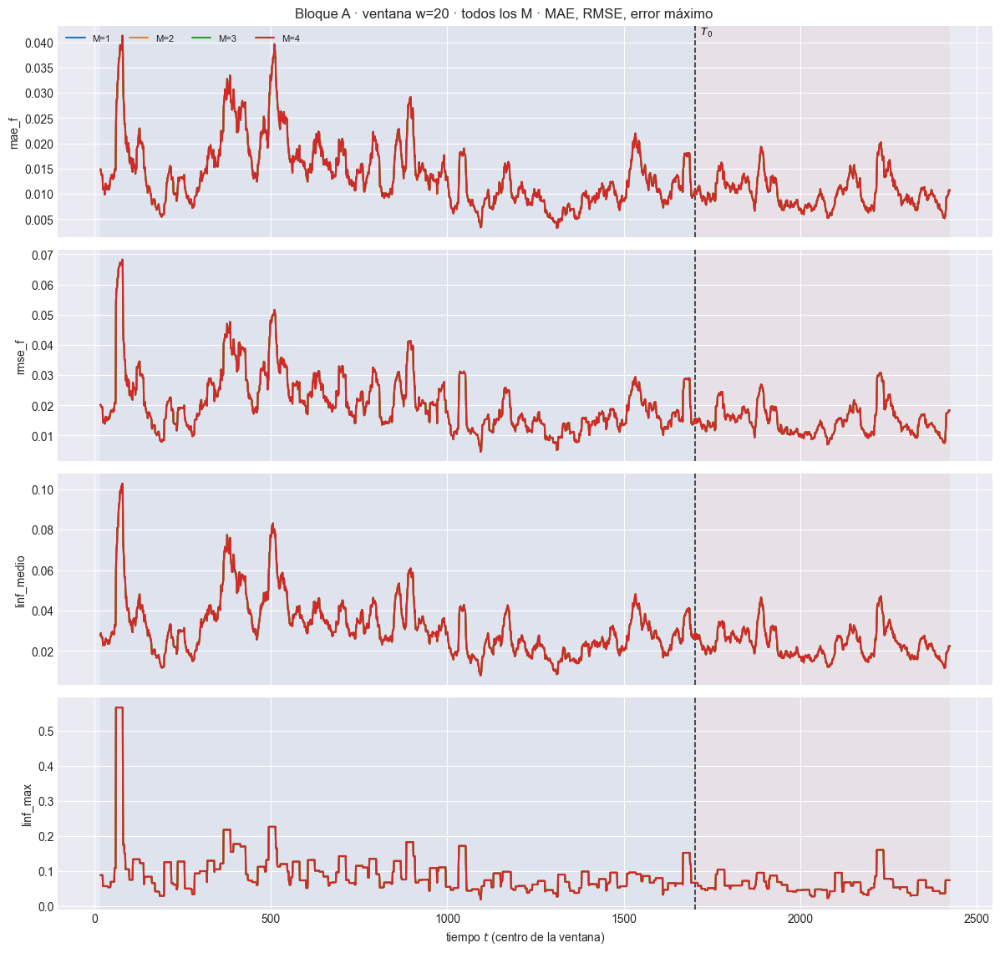

[plot_ventana_movil] inicio (4 pasos)
  1/4 (25.0%) t=0.1s eta=0.2s  mae_f: w=30 train=0.0133  w=30 test=0.009681
  2/4 (50.0%) t=0.1s eta=0.1s  rmse_f: w=30 train=0.01962  w=30 test=0.01441
  3/4 (75.0%) t=0.1s eta=0.0s  linf_medio: w=30 train=0.03089  w=30 test=0.02301
  4/4 (100.0%) t=0.1s eta=0.0s  linf_max: w=30 train=0.09503  w=30 test=0.05966
[plot_ventana_movil] listo: 4 pasos en 0.8s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_barrido_M\85_bloqueA_w30.png


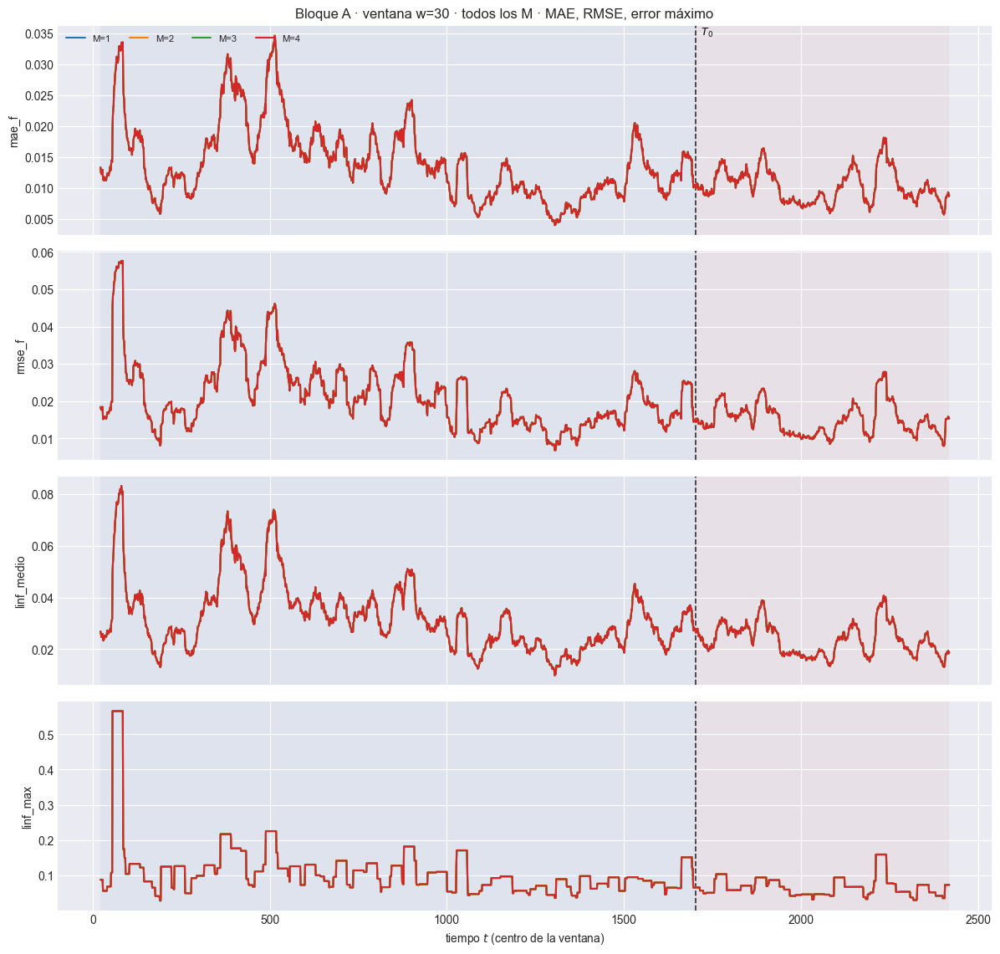

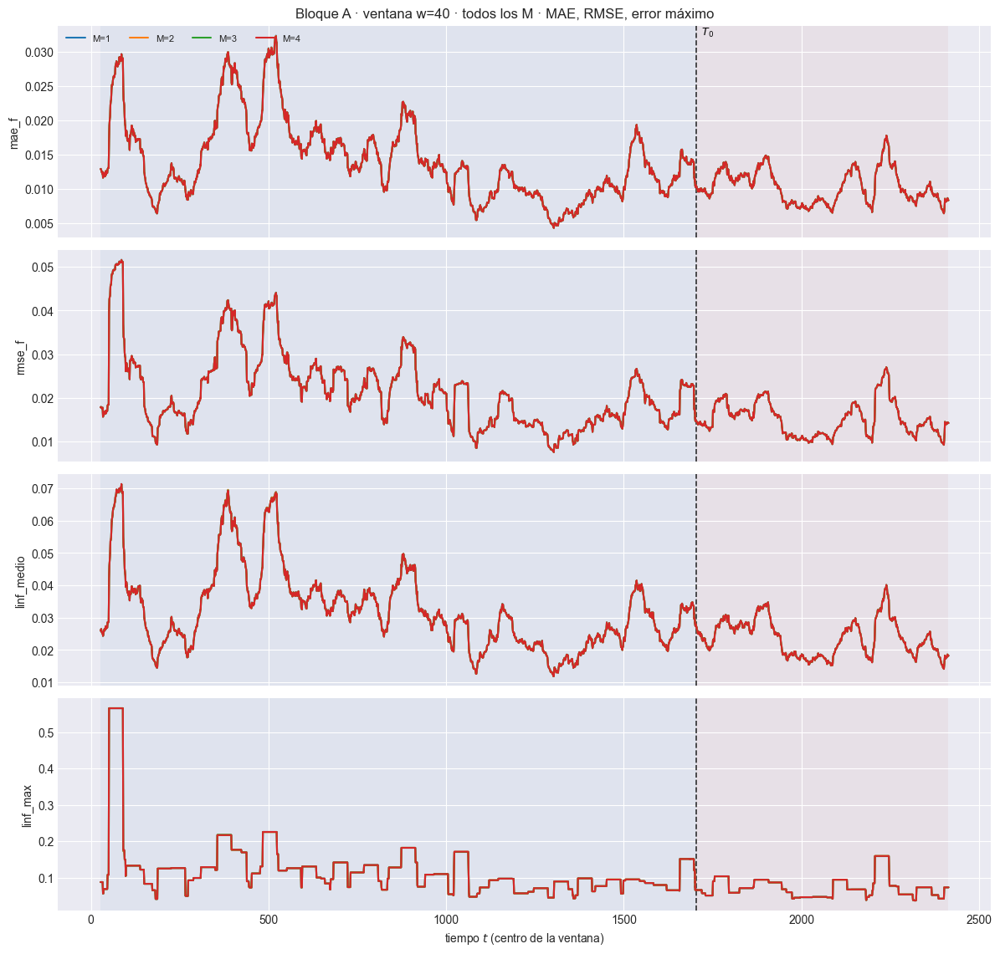

In [7]:
for M in M_OK:
    tablas_ventana(EST[M], DIS, ORIG, PESOS_TAU)
TABLAS_W = apilar_tablas(EST, M_OK, VENTANAS_W, METRICAS_A_COLS + METRICAS_B_COLS)
verificar_relaciones_metricas(EST, M_OK, VENTANAS_W)

# Una figura por ancho con los M superpuestos.
for w in VENTANAS_W:
    plot_ventana_movil(
        TABLAS_W[w], T0, METRICAS_A_COLS, columna_grupo="punto",
        title=f"Bloque A · ventana w={w} · todos los M · MAE, RMSE, error máximo",
        save_path=str(PATH_BARRIDO / f"85_bloqueA_w{w}.png"), verbose=(w == W_REF))
    plt.show()

### 4.1 ¿Qué $M$ gana en cada ventana, y en cada ancho?


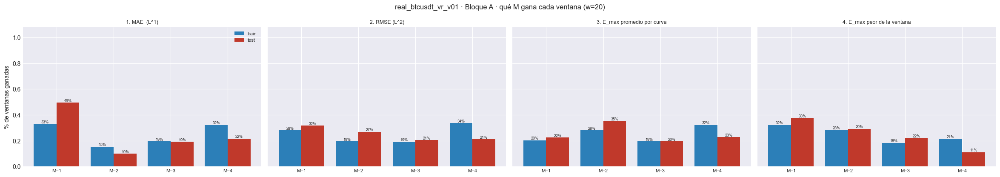

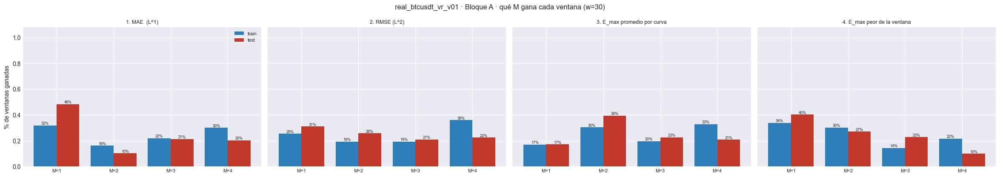

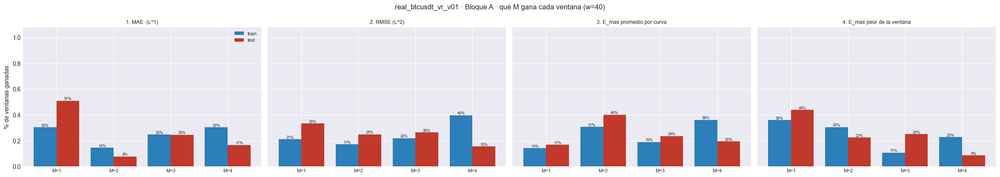

In [8]:
GANA_A = ganancias_por_ventana(EST, M_OK, VENTANAS_W, METRICAS_A, NIVEL)
GANA_B = ganancias_por_ventana(EST, M_OK, VENTANAS_W, METRICAS_B, NIVEL)
GANA_A.to_csv(PATH_BARRIDO / "84_ganador_por_ventana.csv", index=False)
GANA_B.to_csv(PATH_BARRIDO / "87_ganador_bloqueB.csv", index=False)

for w in VENTANAS_W:
    plot_ganador_ventana(GANA_A, METRICAS_A, w, M_OK,
                         f"{EXPERIMENT_BASE} · Bloque A · qué M gana cada ventana (w={w})",
                         PATH_BARRIDO / f"84_ganador_por_ventana_w{w}.png")
    plt.show()

display(tabla_ganadores_test(GANA_A).style.format("{:.1%}")
        .set_caption("Bloque A · % de ventanas TEST ganadas por M (84_ganador_por_ventana.csv)"))

# Salto del MISE en T0, sin las ventanas que lo cruzan.
display(saltos_T0(EST, M_OK, VENTANAS_W).set_index(["M", "w"]).style
        .format({"mise_train": "{:.6f}", "mise_test": "{:.6f}", "salto": "{:.2f}x"})
        .set_caption("MISE train / test y salto en T0"))

## 5. Bloque B: intervalos de predicción, en una sola vista

Cuatro cifras del intervalo, ninguna "primaria" en esta vista -el Winkler es
la única regla de puntuación propia y por eso es la que ordena modelos cuando
hace falta ordenar, pero aquí se muestran las cuatro juntas-:

| | qué es | de qué es |
|---|---|---|
| **Winkler** | interval score | penaliza ancho Y cobertura a la vez |
| **Cobertura simultánea** | de $w$ curvas, cuántas quedan COMPLETAS dentro de su banda (1/0 por curva) | fracción de CURVAS |
| **Cobertura puntual (PICP)** | de una curva, qué fracción de $\tau$ cae dentro | promedio de esa fracción sobre la ventana |
| **MPIW** | ancho medio de la banda | — |

La cobertura simultánea es SIEMPRE $\le$ la puntual: basta un $\tau$ fuera
para que la curva entera cuente como no cubierta.

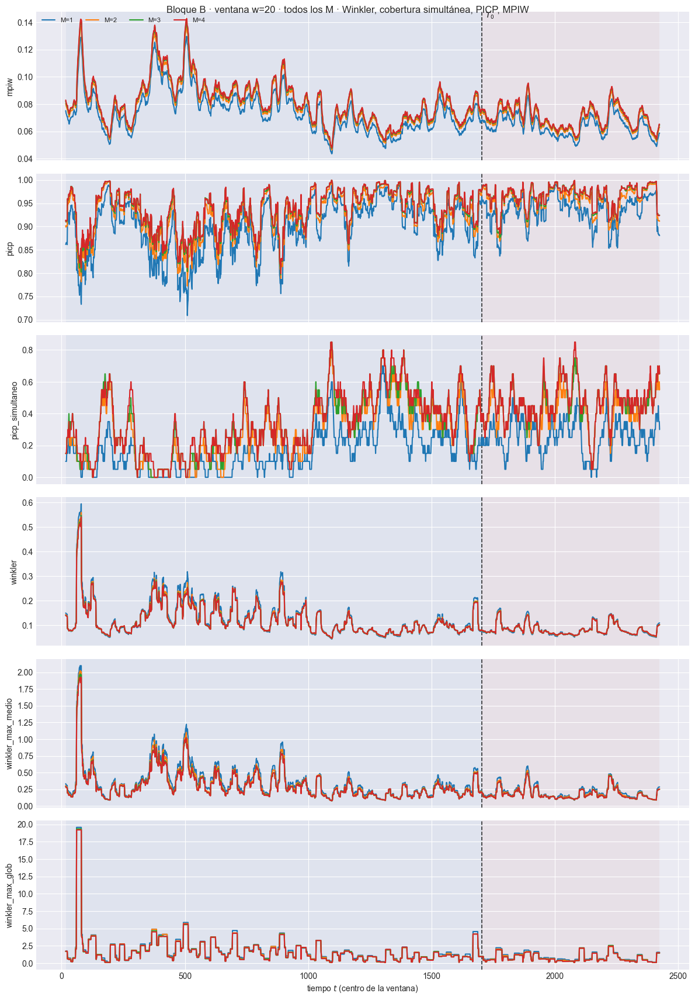

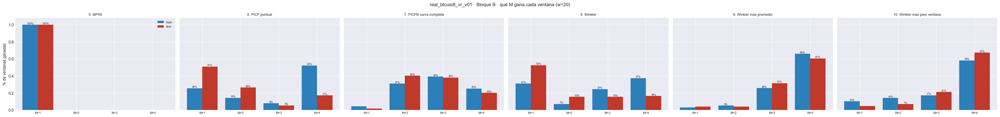

[plot_ventana_movil] inicio (6 pasos)
  1/6 (16.7%) t=0.0s eta=0.2s  mpiw: w=30 train=0.07846  w=30 test=0.06801
  2/6 (33.3%) t=0.1s eta=0.1s  picp: w=30 train=0.9304  w=30 test=0.9619
  3/6 (50.0%) t=0.1s eta=0.1s  picp_simultaneo: w=30 train=0.2333  w=30 test=0.4333
  4/6 (66.7%) t=0.1s eta=0.1s  winkler: w=30 train=0.1042  w=30 test=0.07686
  5/6 (83.3%) t=0.1s eta=0.0s  winkler_max_medio: w=30 train=0.2686  w=30 test=0.1686
  6/6 (100.0%) t=0.2s eta=0.0s  winkler_max_glob: w=30 train=1.764  w=30 test=0.7469
[plot_ventana_movil] listo: 6 pasos en 1.1s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_barrido_M\86_bloqueB_w30.png


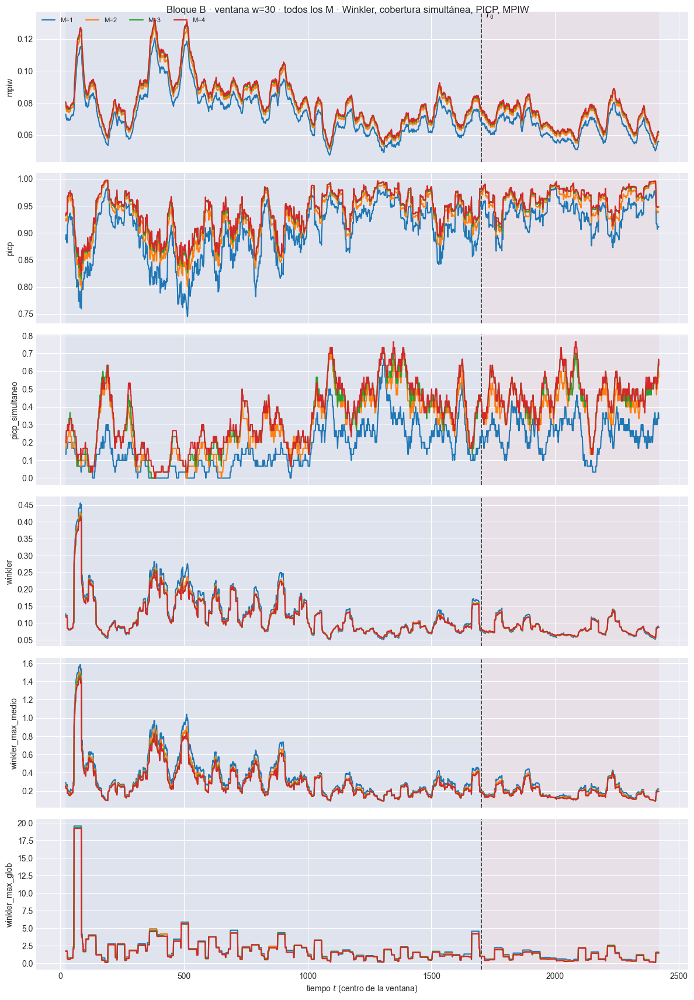

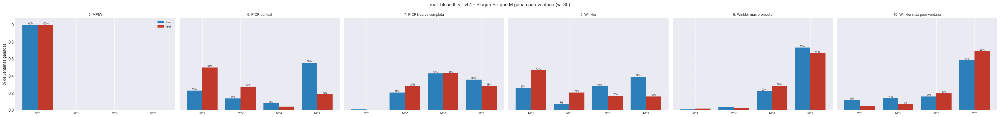

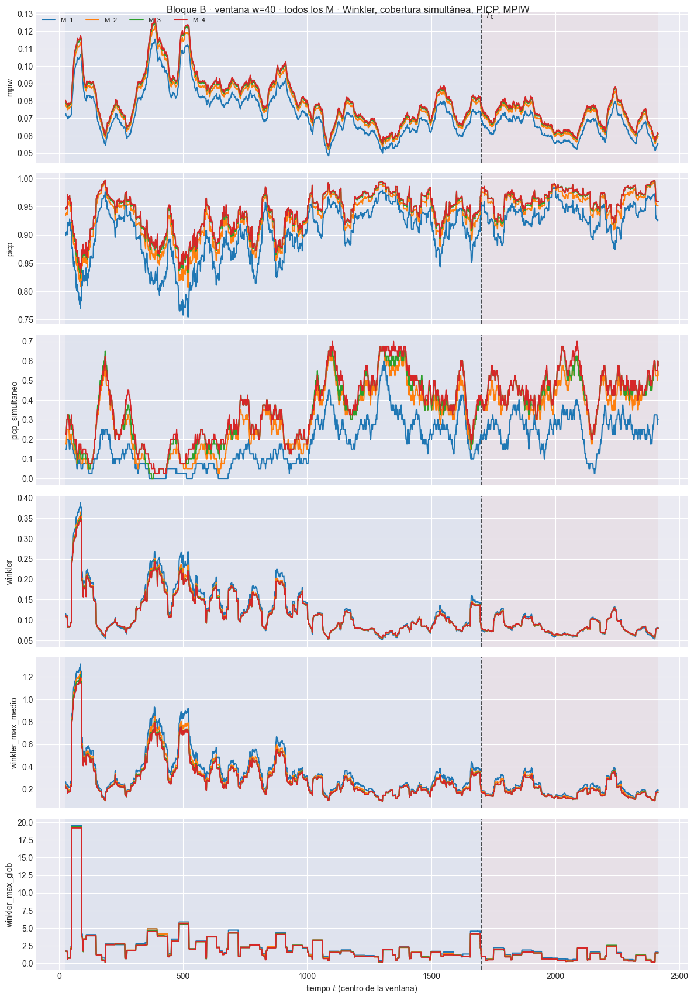

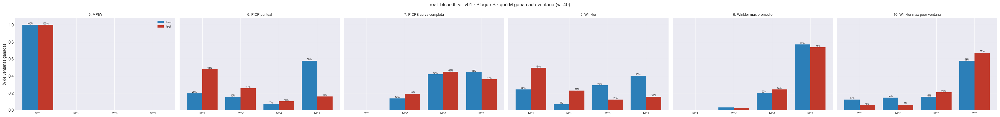

In [9]:
for w in VENTANAS_W:
    plot_ventana_movil(
        TABLAS_W[w], T0, METRICAS_B_COLS, columna_grupo="punto",
        title=f"Bloque B · ventana w={w} · todos los M · Winkler, cobertura simultánea, PICP, MPIW",
        save_path=str(PATH_BARRIDO / f"86_bloqueB_w{w}.png"), verbose=(w == W_REF))
    plt.show()
    # En picp el objetivo es el NOMINAL, no el mínimo.
    plot_ganador_ventana(GANA_B, METRICAS_B, w, M_OK,
                         f"{EXPERIMENT_BASE} · Bloque B · qué M gana cada ventana (w={w})",
                         PATH_BARRIDO / f"87_ganador_bloqueB_w{w}.png")
    plt.show()

display(tabla_ganadores_test(GANA_B).style.format("{:.1%}")
        .set_caption("Bloque B · % de ventanas TEST ganadas por M (87_ganador_bloqueB.csv)"))

## 6. Muestra de predicciones

Dos vistas: un extracto regular del bloque de **prueba** (para no mezclar con
in-sample), y las ventanas con **peor** valor de `METRICA_PEORES` ([CONFIG]).
En la segunda se agrega la curva **anterior** ($t-1$, gris punteada): es el
primer diagnóstico de POR QUÉ el modelo se equivocó -¿la curva de partida ya
era atípica?-.

[plot_extractos_curvas] inicio (25 pasos)
  1/25 ( 4.0%) t=0.0s eta=0.2s  t=1704 [test] cob=0.983 rmse=0.002429
  2/25 ( 8.0%) t=0.0s eta=0.3s  t=1734 [test] cob=0.201 rmse=0.02612
  3/25 (12.0%) t=0.0s eta=0.3s  t=1764 [test] cob=0.931 rmse=0.007422
  4/25 (16.0%) t=0.1s eta=0.3s  t=1794 [test] cob=0.948 rmse=0.01398
  5/25 (20.0%) t=0.1s eta=0.3s  t=1824 [test] cob=0.990 rmse=0.01067
  6/25 (24.0%) t=0.1s eta=0.3s  t=1854 [test] cob=0.983 rmse=0.007193
  7/25 (28.0%) t=0.1s eta=0.3s  t=1884 [test] cob=0.993 rmse=0.01582
  8/25 (32.0%) t=0.1s eta=0.3s  t=1914 [test] cob=1.000 rmse=0.01803
  9/25 (36.0%) t=0.1s eta=0.3s  t=1944 [test] cob=0.931 rmse=0.008746
  10/25 (40.0%) t=0.2s eta=0.2s  t=1974 [test] cob=0.993 rmse=0.009069
  11/25 (44.0%) t=0.2s eta=0.2s  t=2004 [test] cob=0.990 rmse=0.002608
  12/25 (48.0%) t=0.2s eta=0.2s  t=2034 [test] cob=1.000 rmse=0.005964
  13/25 (52.0%) t=0.2s eta=0.2s  t=2064 [test] cob=0.955 rmse=0.005875
  14/25 (56.0%) t=0.2s eta=0.2s  t=2094 [test] co

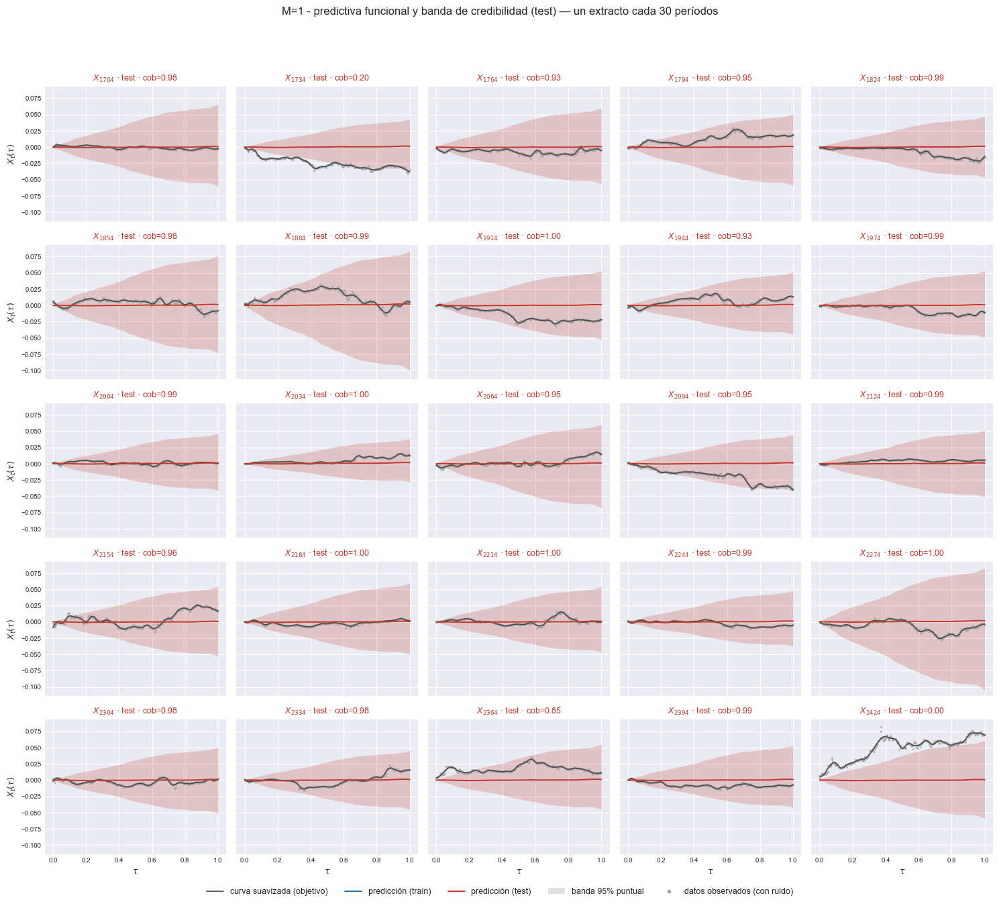

[plot_extractos_curvas] inicio (25 pasos)
  1/25 ( 4.0%) t=0.0s eta=0.1s  t=1704 [test] cob=1.000 rmse=0.002424
  2/25 ( 8.0%) t=0.0s eta=0.2s  t=1734 [test] cob=0.514 rmse=0.02613
  3/25 (12.0%) t=0.0s eta=0.2s  t=1764 [test] cob=0.951 rmse=0.007432
  4/25 (16.0%) t=0.0s eta=0.2s  t=1794 [test] cob=0.997 rmse=0.01398
  5/25 (20.0%) t=0.1s eta=0.2s  t=1824 [test] cob=0.997 rmse=0.01062
  6/25 (24.0%) t=0.1s eta=0.2s  t=1854 [test] cob=0.986 rmse=0.007172
  7/25 (28.0%) t=0.1s eta=0.2s  t=1884 [test] cob=0.997 rmse=0.01618
  8/25 (32.0%) t=0.1s eta=0.2s  t=1914 [test] cob=1.000 rmse=0.01803
  9/25 (36.0%) t=0.1s eta=0.2s  t=1944 [test] cob=0.990 rmse=0.008702
  10/25 (40.0%) t=0.1s eta=0.2s  t=1974 [test] cob=0.997 rmse=0.009019
  11/25 (44.0%) t=0.1s eta=0.2s  t=2004 [test] cob=0.993 rmse=0.002573
  12/25 (48.0%) t=0.2s eta=0.2s  t=2034 [test] cob=1.000 rmse=0.005985
  13/25 (52.0%) t=0.2s eta=0.2s  t=2064 [test] cob=0.965 rmse=0.005896
  14/25 (56.0%) t=0.2s eta=0.1s  t=2094 [test] co

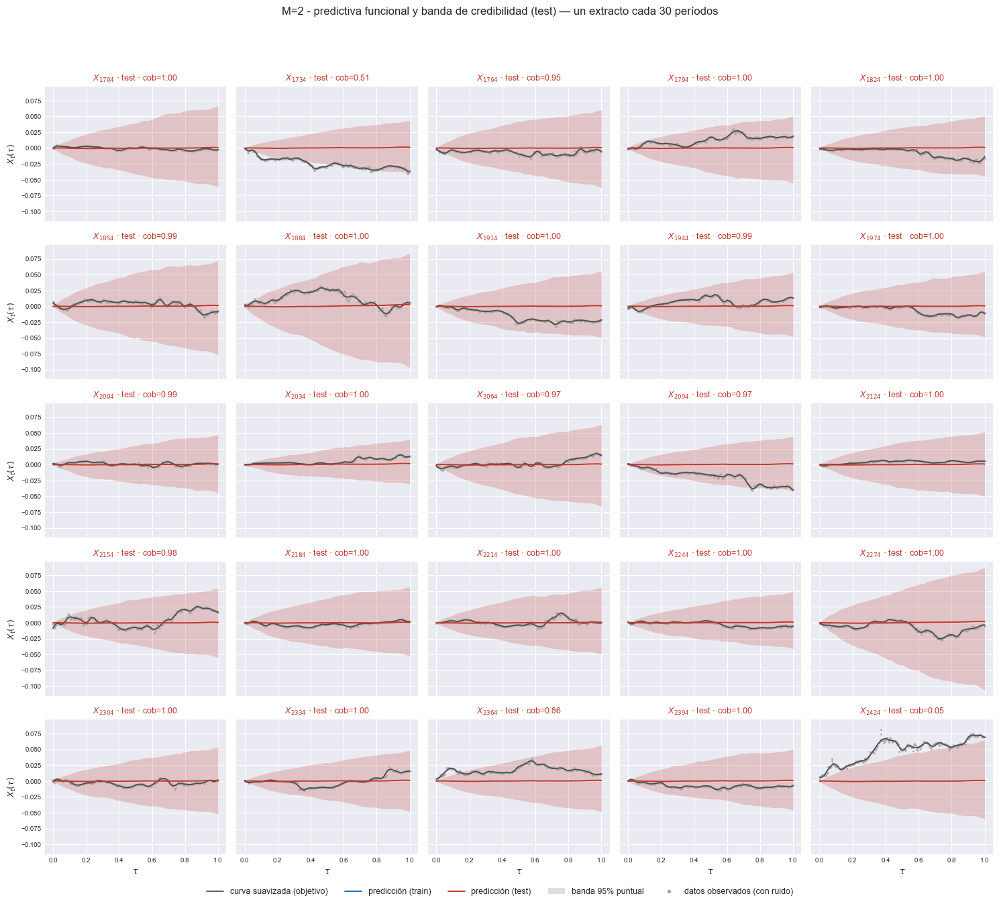

[plot_extractos_curvas] inicio (25 pasos)
  1/25 ( 4.0%) t=0.0s eta=0.1s  t=1704 [test] cob=1.000 rmse=0.002399
  2/25 ( 8.0%) t=0.0s eta=0.2s  t=1734 [test] cob=0.521 rmse=0.02613
  3/25 (12.0%) t=0.0s eta=0.2s  t=1764 [test] cob=0.962 rmse=0.007428
  4/25 (16.0%) t=0.0s eta=0.2s  t=1794 [test] cob=0.997 rmse=0.01399
  5/25 (20.0%) t=0.1s eta=0.2s  t=1824 [test] cob=0.997 rmse=0.01065
  6/25 (24.0%) t=0.1s eta=0.2s  t=1854 [test] cob=0.990 rmse=0.007171
  7/25 (28.0%) t=0.1s eta=0.2s  t=1884 [test] cob=0.997 rmse=0.01615
  8/25 (32.0%) t=0.1s eta=0.3s  t=1914 [test] cob=1.000 rmse=0.01801
  9/25 (36.0%) t=0.2s eta=0.3s  t=1944 [test] cob=0.990 rmse=0.008719
  10/25 (40.0%) t=0.2s eta=0.3s  t=1974 [test] cob=0.997 rmse=0.009022
  11/25 (44.0%) t=0.2s eta=0.2s  t=2004 [test] cob=0.993 rmse=0.002492
  12/25 (48.0%) t=0.2s eta=0.2s  t=2034 [test] cob=1.000 rmse=0.005959
  13/25 (52.0%) t=0.2s eta=0.2s  t=2064 [test] cob=0.972 rmse=0.005881
  14/25 (56.0%) t=0.2s eta=0.2s  t=2094 [test] co

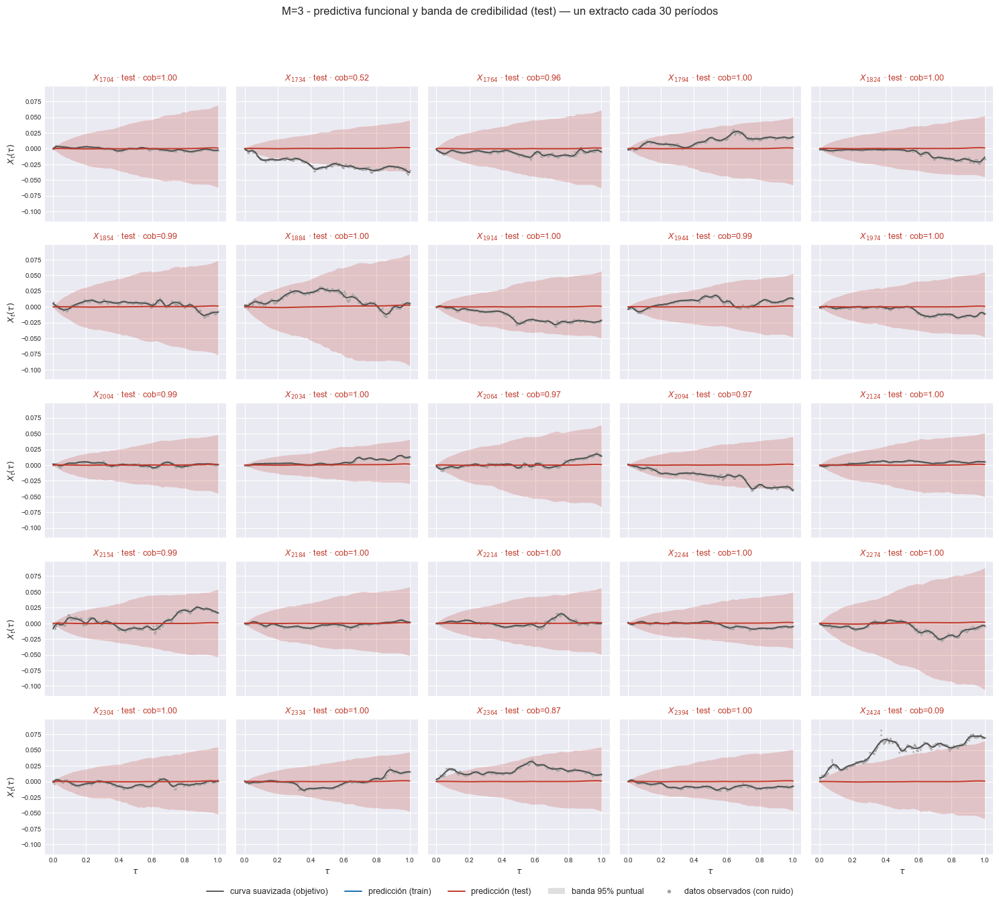

[plot_extractos_curvas] inicio (25 pasos)
  1/25 ( 4.0%) t=0.0s eta=0.1s  t=1704 [test] cob=1.000 rmse=0.002401
  2/25 ( 8.0%) t=0.0s eta=0.2s  t=1734 [test] cob=0.521 rmse=0.02613
  3/25 (12.0%) t=0.0s eta=0.2s  t=1764 [test] cob=0.965 rmse=0.007442
  4/25 (16.0%) t=0.0s eta=0.2s  t=1794 [test] cob=0.997 rmse=0.01399
  5/25 (20.0%) t=0.1s eta=0.2s  t=1824 [test] cob=0.997 rmse=0.01065
  6/25 (24.0%) t=0.1s eta=0.2s  t=1854 [test] cob=0.990 rmse=0.007156
  7/25 (28.0%) t=0.1s eta=0.2s  t=1884 [test] cob=0.997 rmse=0.01615
  8/25 (32.0%) t=0.1s eta=0.2s  t=1914 [test] cob=1.000 rmse=0.01801
  9/25 (36.0%) t=0.1s eta=0.2s  t=1944 [test] cob=0.990 rmse=0.008721
  10/25 (40.0%) t=0.1s eta=0.2s  t=1974 [test] cob=0.997 rmse=0.009021
  11/25 (44.0%) t=0.1s eta=0.2s  t=2004 [test] cob=0.993 rmse=0.002485
  12/25 (48.0%) t=0.1s eta=0.2s  t=2034 [test] cob=1.000 rmse=0.005949
  13/25 (52.0%) t=0.2s eta=0.1s  t=2064 [test] cob=0.972 rmse=0.005866
  14/25 (56.0%) t=0.2s eta=0.1s  t=2094 [test] co

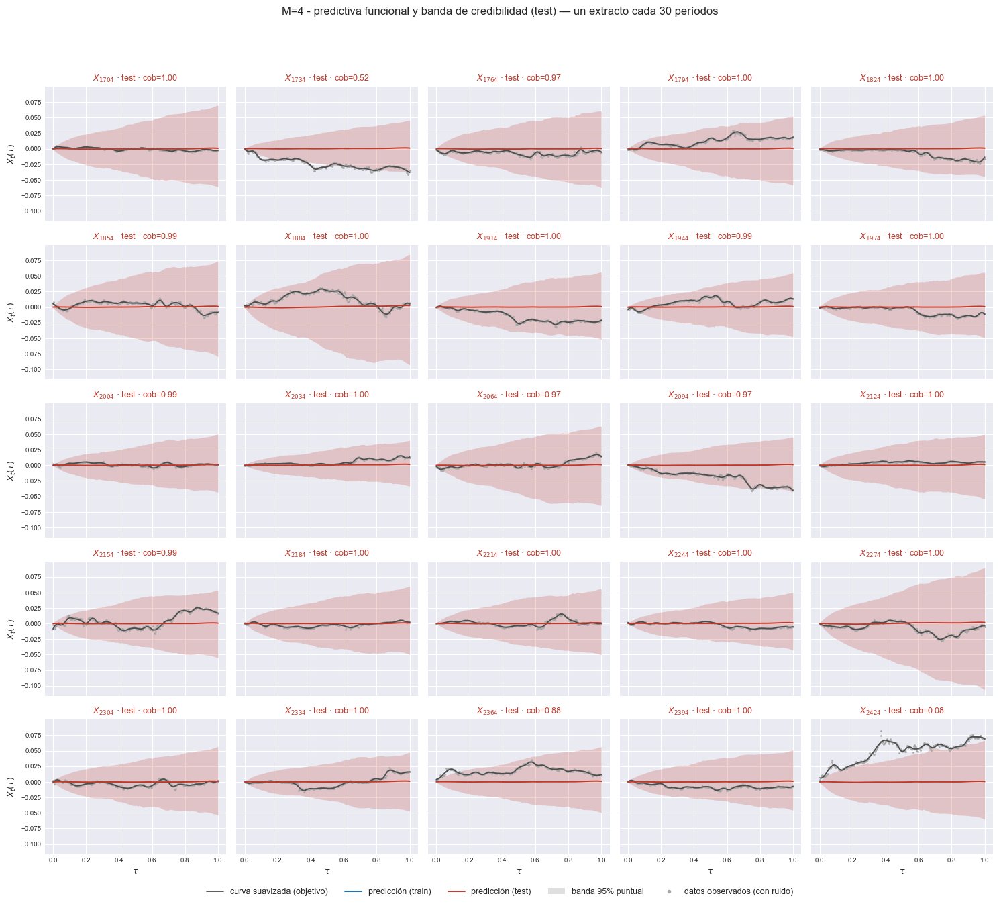

In [10]:
# Extractos regulares, SOLO del bloque de prueba.
mask_test = ~es_train
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_obj_ev[mask_test], e["X_pred"][mask_test], e["li_f"][mask_test], e["ls_f"][mask_test],
        grilla, T0, t=t_orig[mask_test], cada=CADA, n_col=5, nivel=NIVEL,
        etiqueta_objetivo="curva suavizada (objetivo)", X_obs=X_obs_ev[mask_test],
        title=f"M={M} - predictiva funcional y banda de credibilidad (test)",
        save_path=str(e["paths"]["out_report"] / "54_extractos_curvas_test.png"), verbose=True)
    plt.show()

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1700 [train] cob=0.910 rmse=0.01997
  2/7 (28.6%) t=0.0s eta=0.0s  t=1701 [train] cob=0.965 rmse=0.006755
  3/7 (42.9%) t=0.0s eta=0.0s  t=1702 [train] cob=1.000 rmse=0.01441
  4/7 (57.1%) t=0.0s eta=0.0s  t=1703 [train] cob=0.990 rmse=0.007571
  5/7 (71.4%) t=0.0s eta=0.0s  t=1704 [test] cob=0.983 rmse=0.002429
  6/7 (85.7%) t=0.0s eta=0.0s  t=1705 [test] cob=0.941 rmse=0.01447
  7/7 (100.0%) t=0.0s eta=0.0s  t=1706 [test] cob=0.979 rmse=0.01834
[plot_extractos_curvas] listo: 7 pasos en 1.3s  cob media train=0.966 test=0.968 (nominal 0.95)


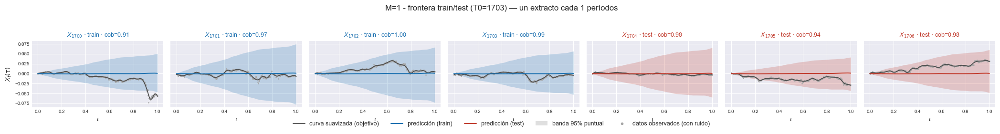

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1700 [train] cob=0.913 rmse=0.01993
  2/7 (28.6%) t=0.0s eta=0.0s  t=1701 [train] cob=1.000 rmse=0.00687
  3/7 (42.9%) t=0.0s eta=0.0s  t=1702 [train] cob=1.000 rmse=0.01448
  4/7 (57.1%) t=0.0s eta=0.0s  t=1703 [train] cob=0.993 rmse=0.007587
  5/7 (71.4%) t=0.0s eta=0.0s  t=1704 [test] cob=1.000 rmse=0.002424
  6/7 (85.7%) t=0.0s eta=0.0s  t=1705 [test] cob=0.993 rmse=0.01449
  7/7 (100.0%) t=0.0s eta=0.0s  t=1706 [test] cob=1.000 rmse=0.01834
[plot_extractos_curvas] listo: 7 pasos en 1.2s  cob media train=0.977 test=0.998 (nominal 0.95)


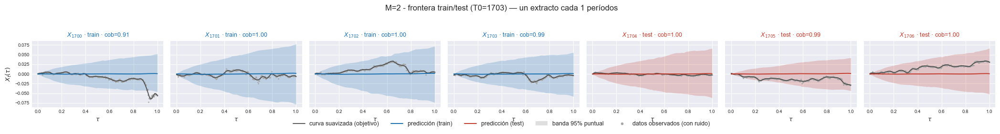

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1700 [train] cob=0.913 rmse=0.01993
  2/7 (28.6%) t=0.0s eta=0.0s  t=1701 [train] cob=1.000 rmse=0.006863
  3/7 (42.9%) t=0.0s eta=0.0s  t=1702 [train] cob=1.000 rmse=0.01445
  4/7 (57.1%) t=0.0s eta=0.0s  t=1703 [train] cob=0.993 rmse=0.007601
  5/7 (71.4%) t=0.0s eta=0.0s  t=1704 [test] cob=1.000 rmse=0.002399
  6/7 (85.7%) t=0.0s eta=0.0s  t=1705 [test] cob=0.983 rmse=0.01449
  7/7 (100.0%) t=0.0s eta=0.0s  t=1706 [test] cob=1.000 rmse=0.01835
[plot_extractos_curvas] listo: 7 pasos en 1.5s  cob media train=0.977 test=0.994 (nominal 0.95)


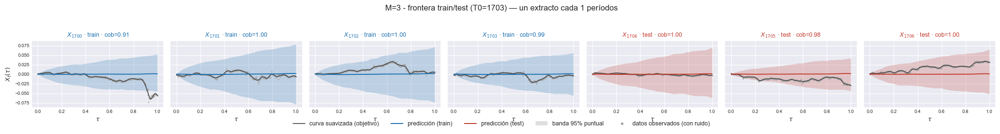

[plot_extractos_curvas] inicio (7 pasos)
  1/7 (14.3%) t=0.0s eta=0.0s  t=1700 [train] cob=0.913 rmse=0.01991
  2/7 (28.6%) t=0.0s eta=0.0s  t=1701 [train] cob=1.000 rmse=0.006897
  3/7 (42.9%) t=0.0s eta=0.0s  t=1702 [train] cob=1.000 rmse=0.01443
  4/7 (57.1%) t=0.0s eta=0.0s  t=1703 [train] cob=0.993 rmse=0.007617
  5/7 (71.4%) t=0.0s eta=0.0s  t=1704 [test] cob=1.000 rmse=0.002401
  6/7 (85.7%) t=0.0s eta=0.0s  t=1705 [test] cob=0.979 rmse=0.01448
  7/7 (100.0%) t=0.0s eta=0.0s  t=1706 [test] cob=1.000 rmse=0.01835
[plot_extractos_curvas] listo: 7 pasos en 1.1s  cob media train=0.977 test=0.993 (nominal 0.95)


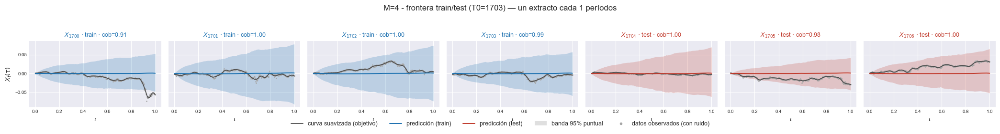

In [11]:
# Zoom sobre la frontera: los últimos orígenes de train y los primeros de test.
i_corte = int(np.searchsorted(t_orig, T0))
sel = np.arange(max(0, i_corte - 3), min(n_orig, i_corte + 4))
for M in M_OK:
    e = EST[M]
    plot_extractos_curvas(
        X_obj_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel], grilla, T0,
        t=t_orig[sel], cada=1, n_col=len(sel), nivel=NIVEL,
        etiqueta_objetivo="curva suavizada (objetivo)", X_obs=X_obs_ev[sel],
        title=f"M={M} - frontera train/test (T0={T0})",
        save_path=str(e["paths"]["out_report"] / "55_extractos_frontera.png"), verbose=True)
    plt.show()

[M=1] peores 5 ventanas por rmse_f (w=30, test, sin cruzar T0)
    t=[2225, 2254]  rmse_f=0.027873


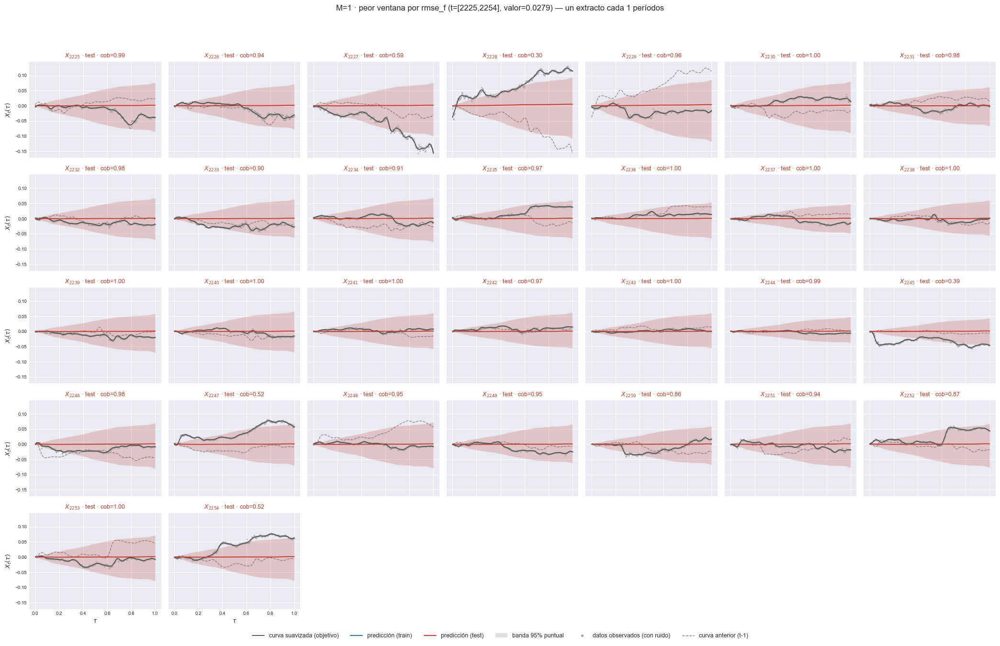

    t=[2220, 2249]  rmse_f=0.027846


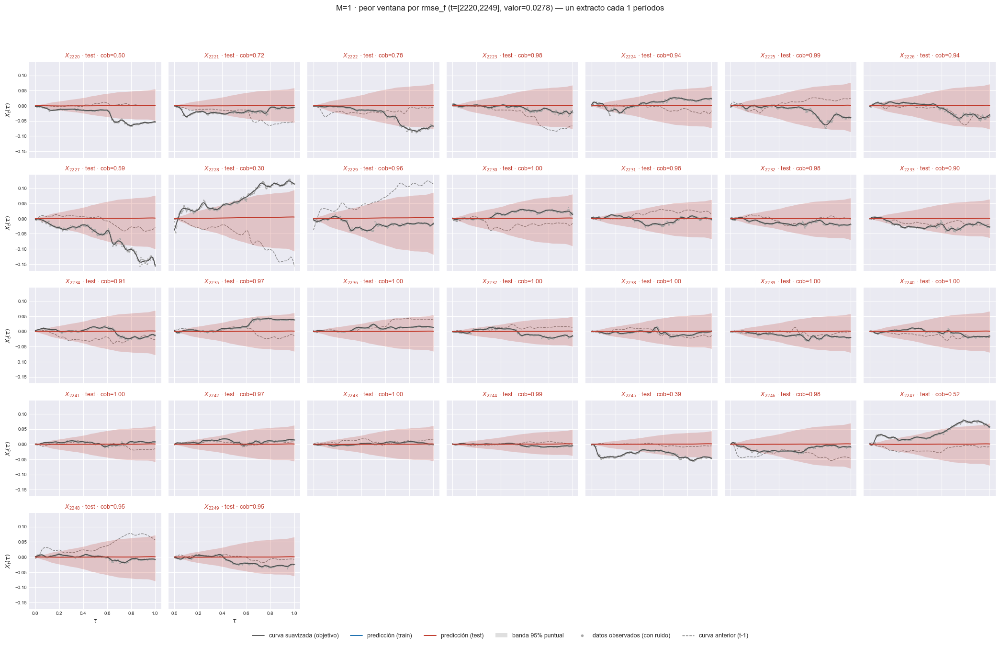

    t=[2227, 2256]  rmse_f=0.027676


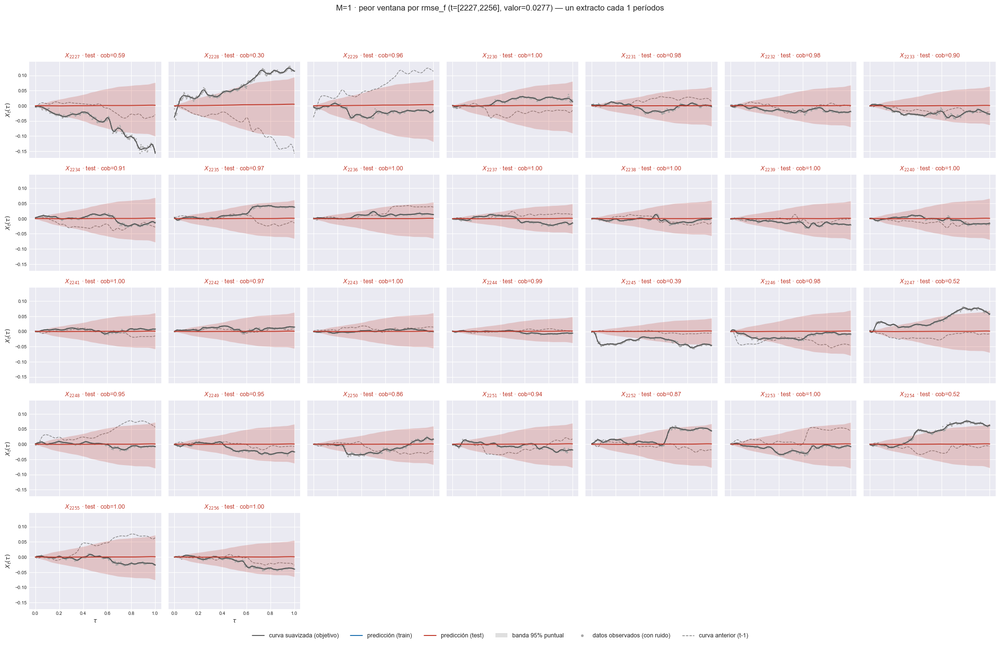

    t=[2219, 2248]  rmse_f=0.027624


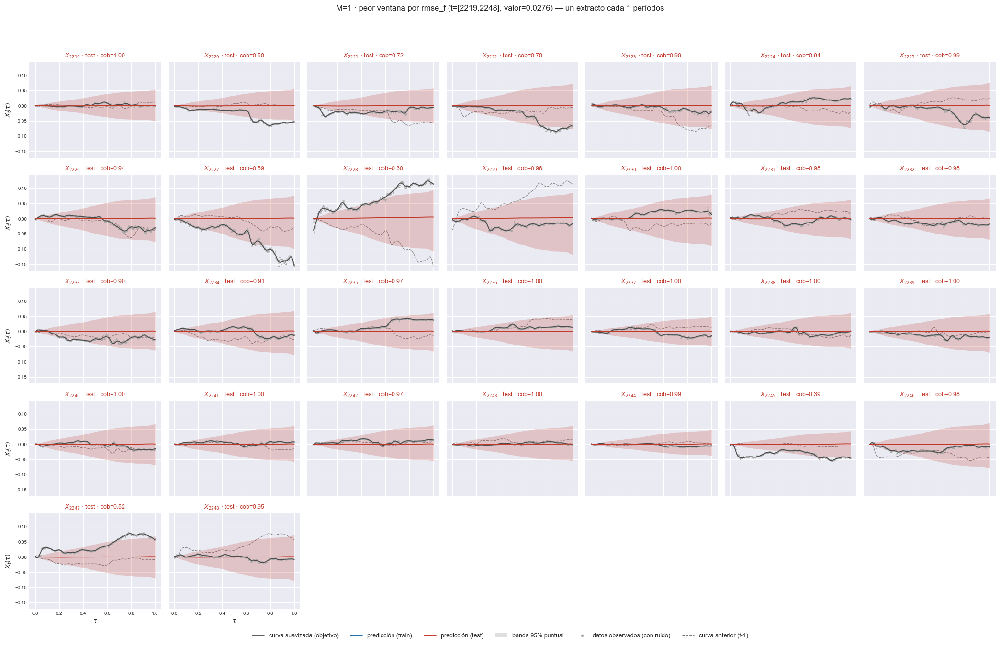

    t=[2218, 2247]  rmse_f=0.027605


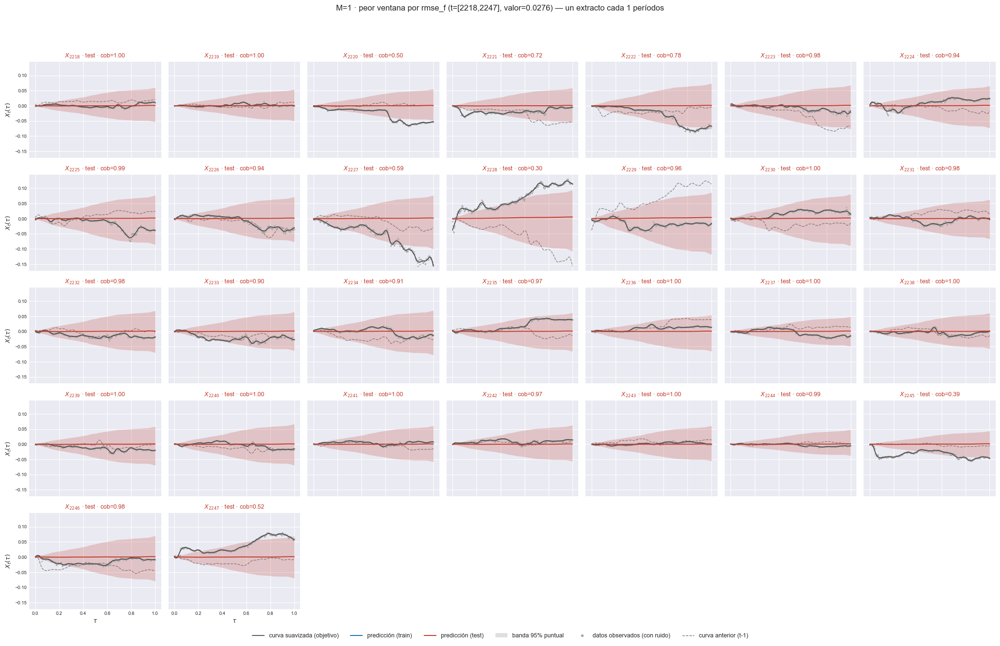

[M=2] peores 5 ventanas por rmse_f (w=30, test, sin cruzar T0)
    t=[2225, 2254]  rmse_f=0.027879


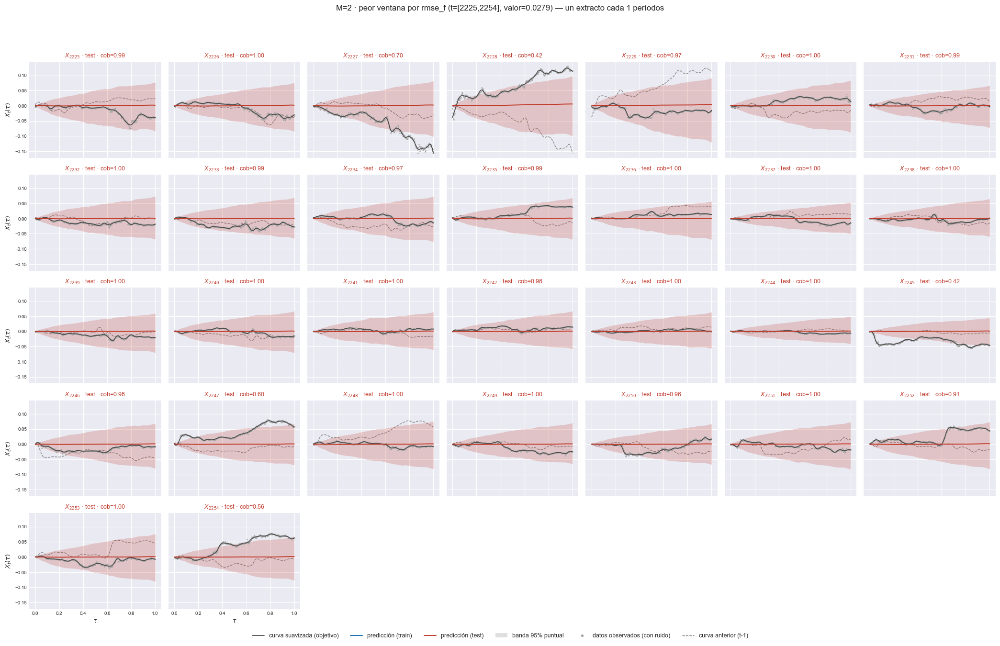

    t=[2220, 2249]  rmse_f=0.027854


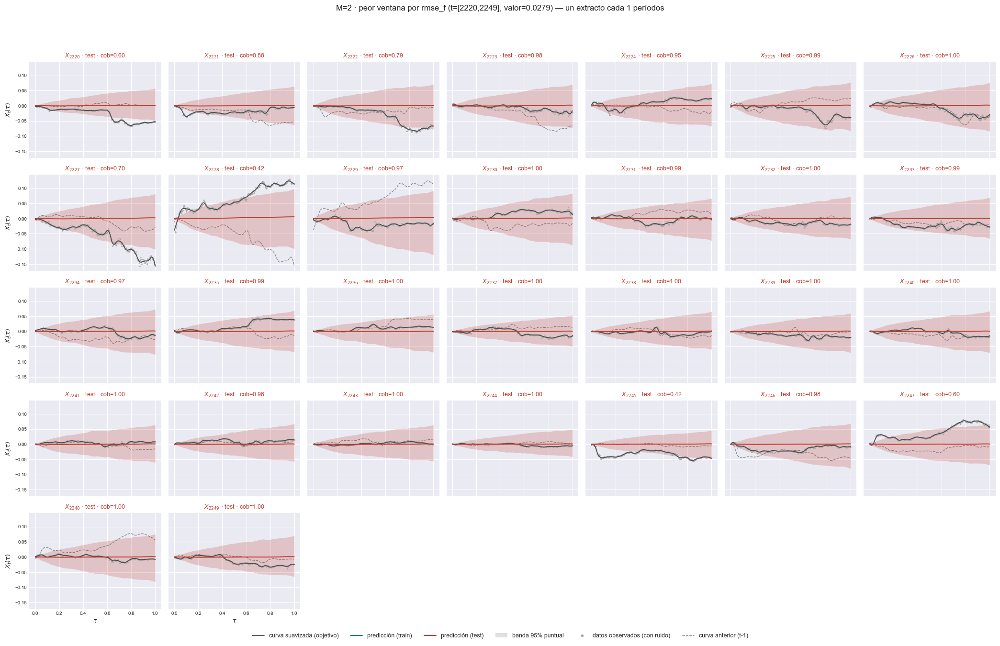

    t=[2227, 2256]  rmse_f=0.027676


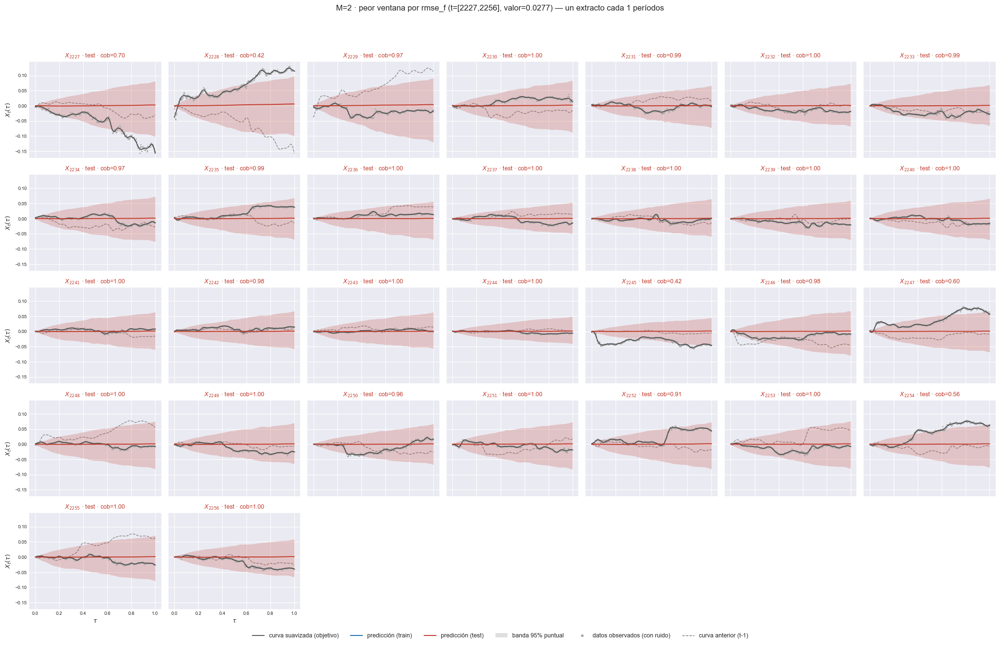

    t=[2219, 2248]  rmse_f=0.027632


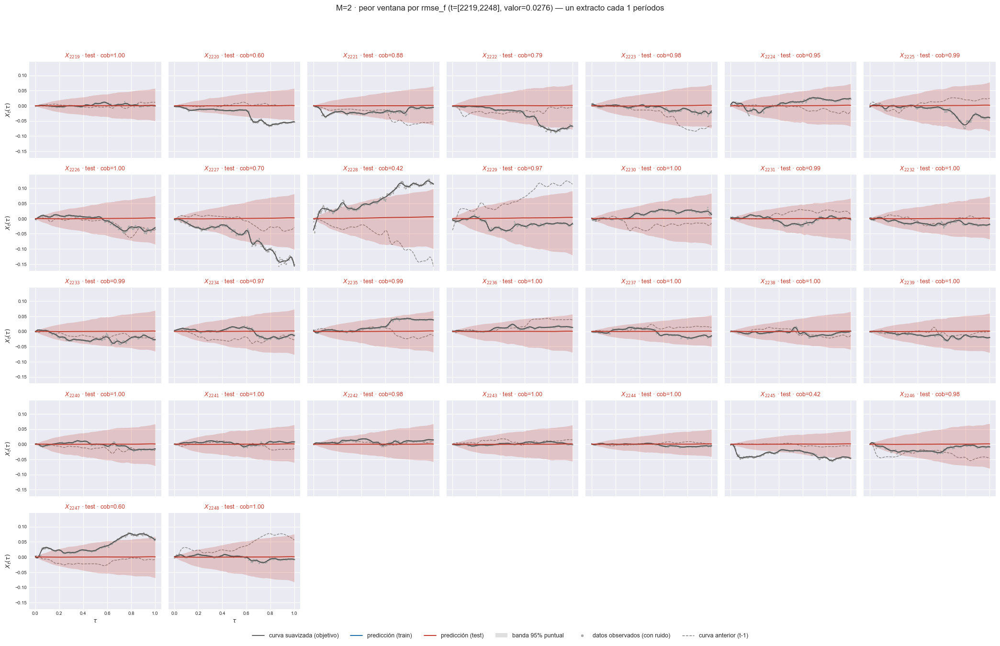

    t=[2218, 2247]  rmse_f=0.027612


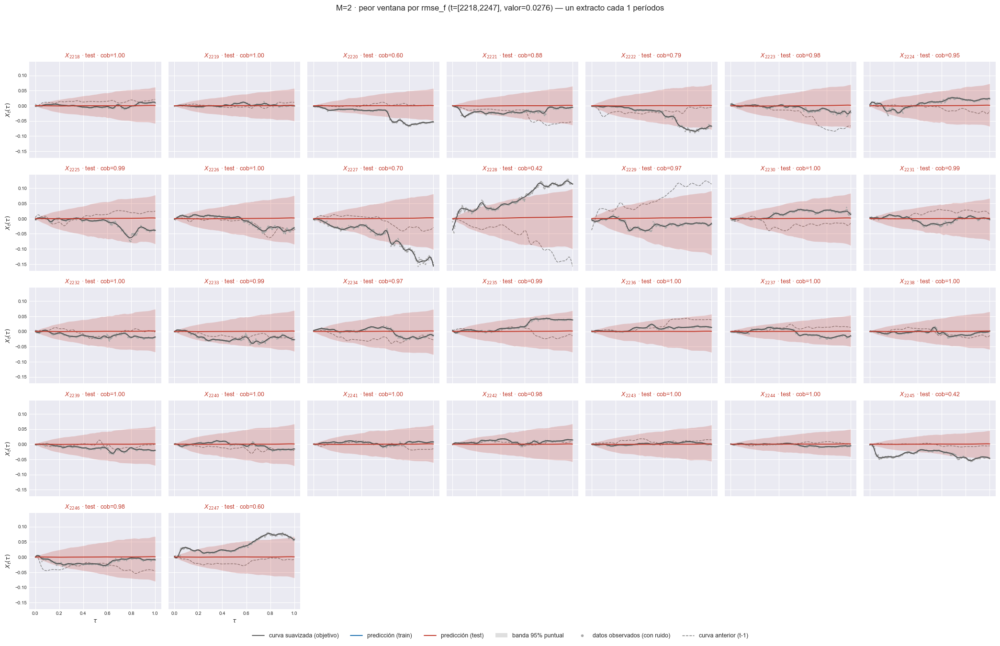

[M=3] peores 5 ventanas por rmse_f (w=30, test, sin cruzar T0)
    t=[2225, 2254]  rmse_f=0.027874


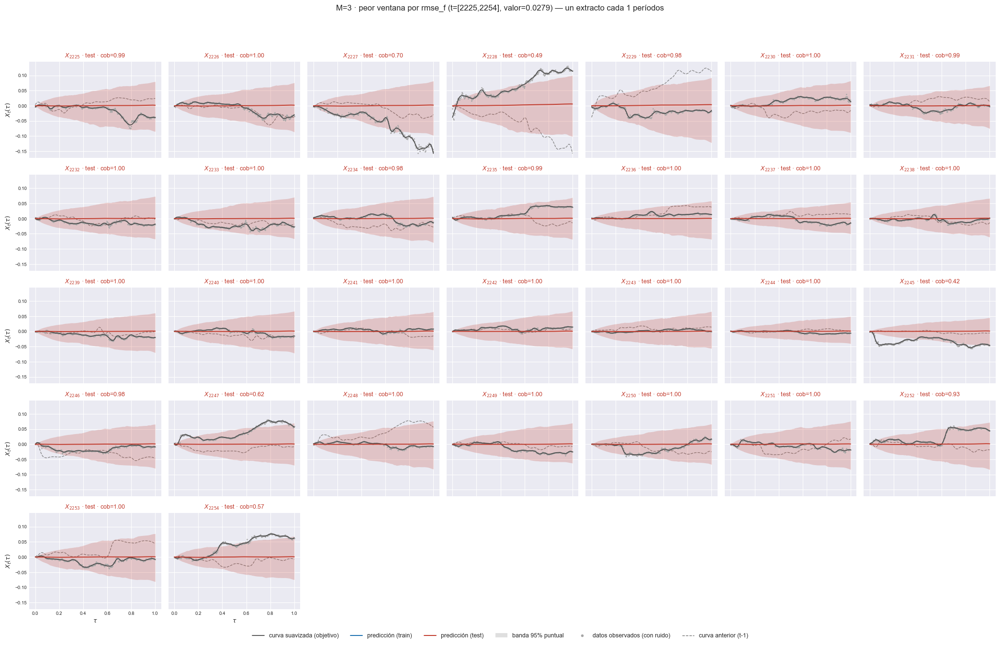

    t=[2220, 2249]  rmse_f=0.027851


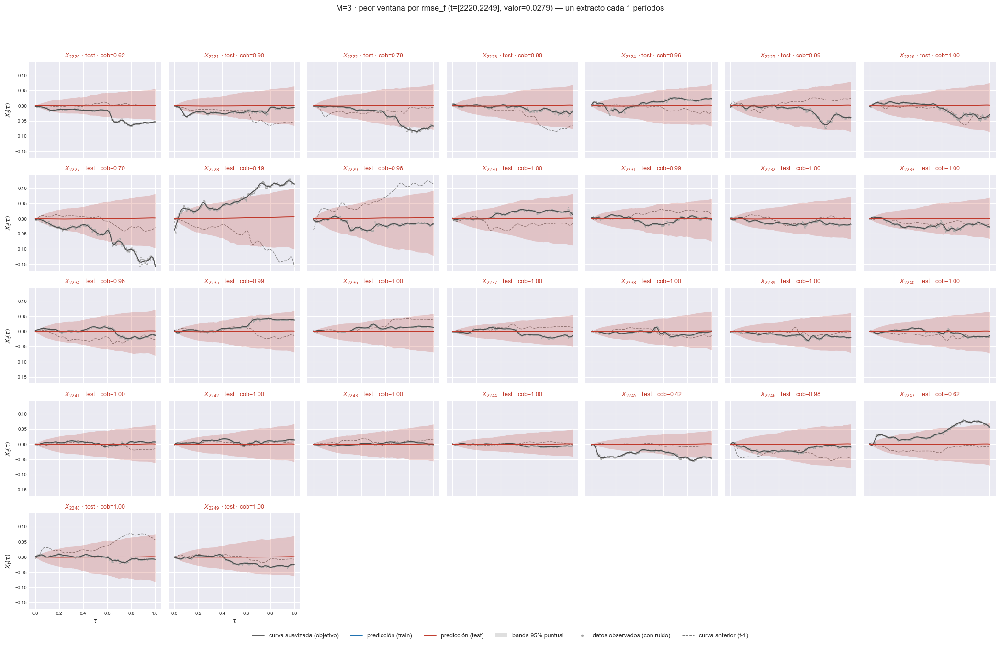

    t=[2227, 2256]  rmse_f=0.027672


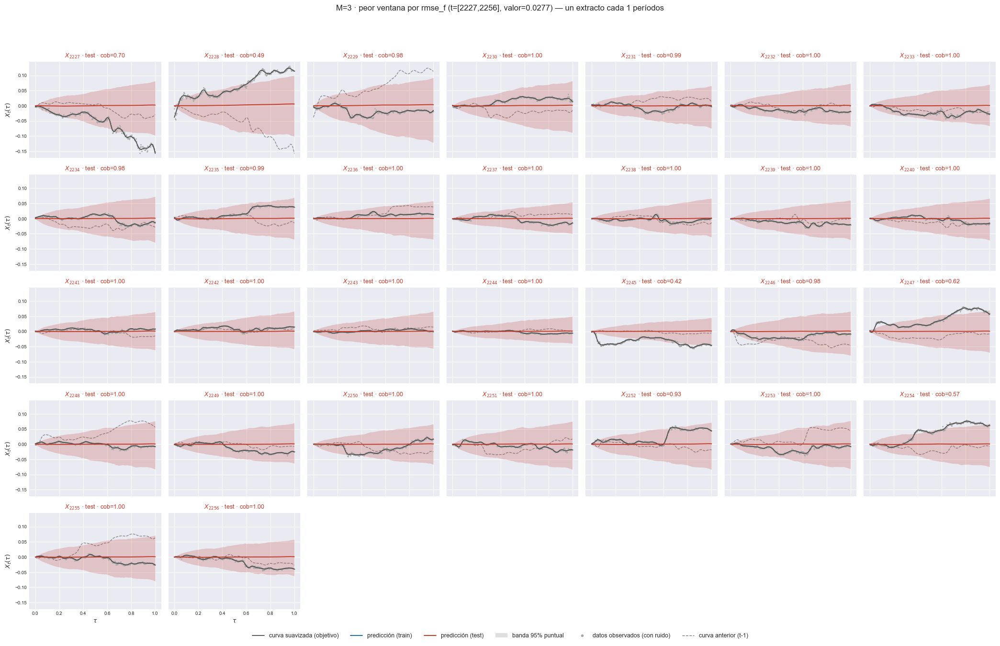

    t=[2219, 2248]  rmse_f=0.027630


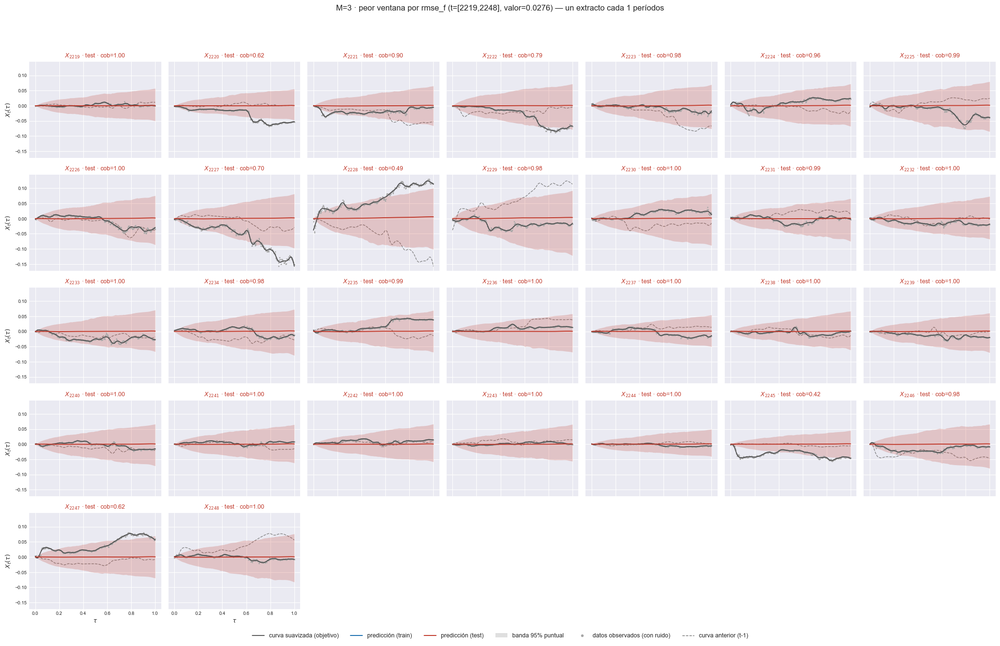

    t=[2218, 2247]  rmse_f=0.027610


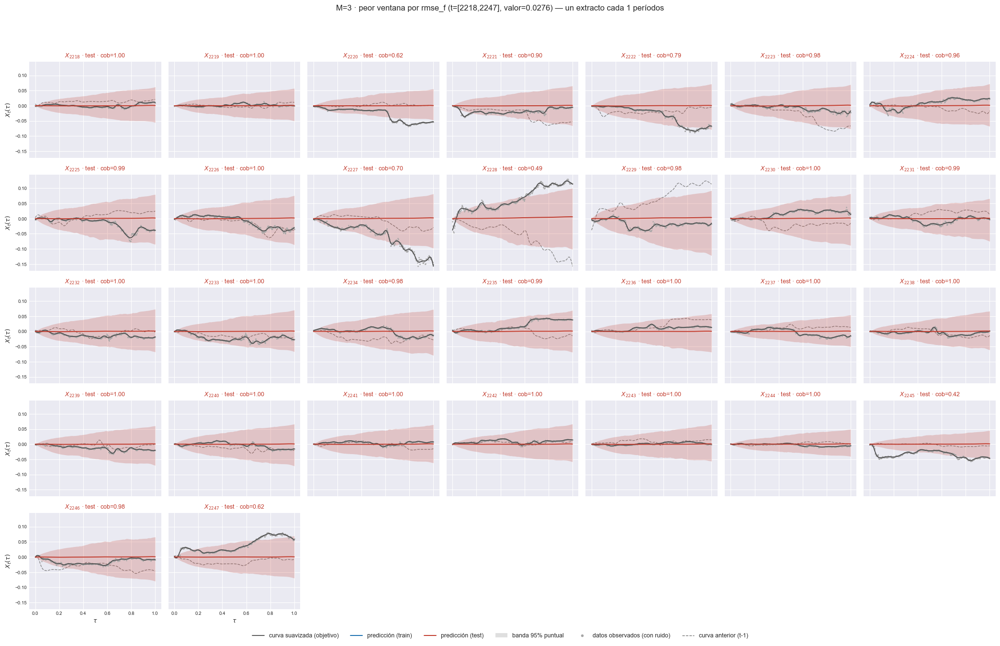

[M=4] peores 5 ventanas por rmse_f (w=30, test, sin cruzar T0)
    t=[2225, 2254]  rmse_f=0.027877


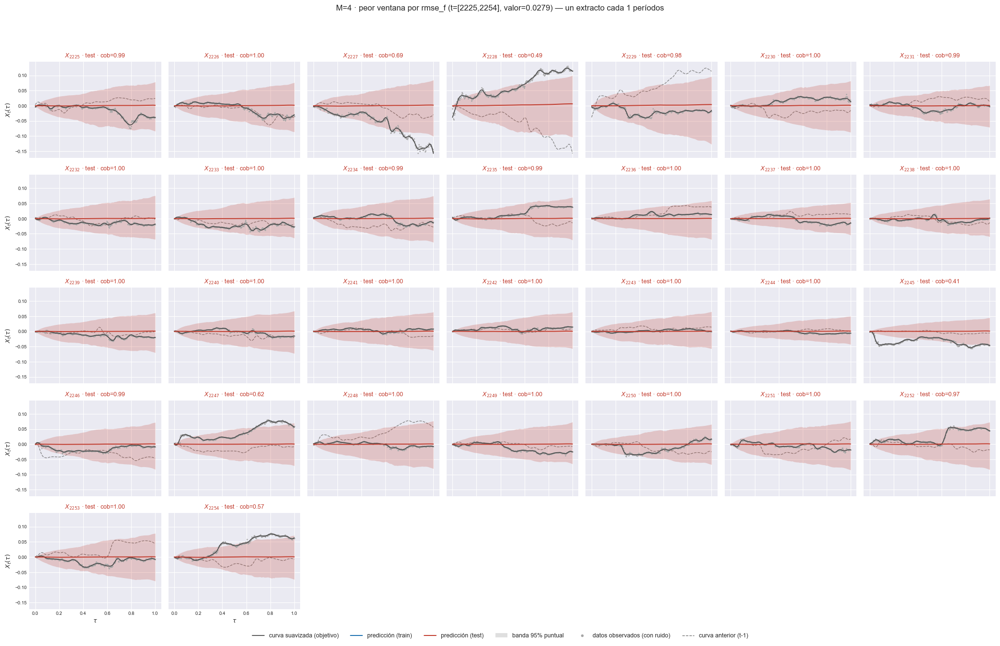

    t=[2220, 2249]  rmse_f=0.027855


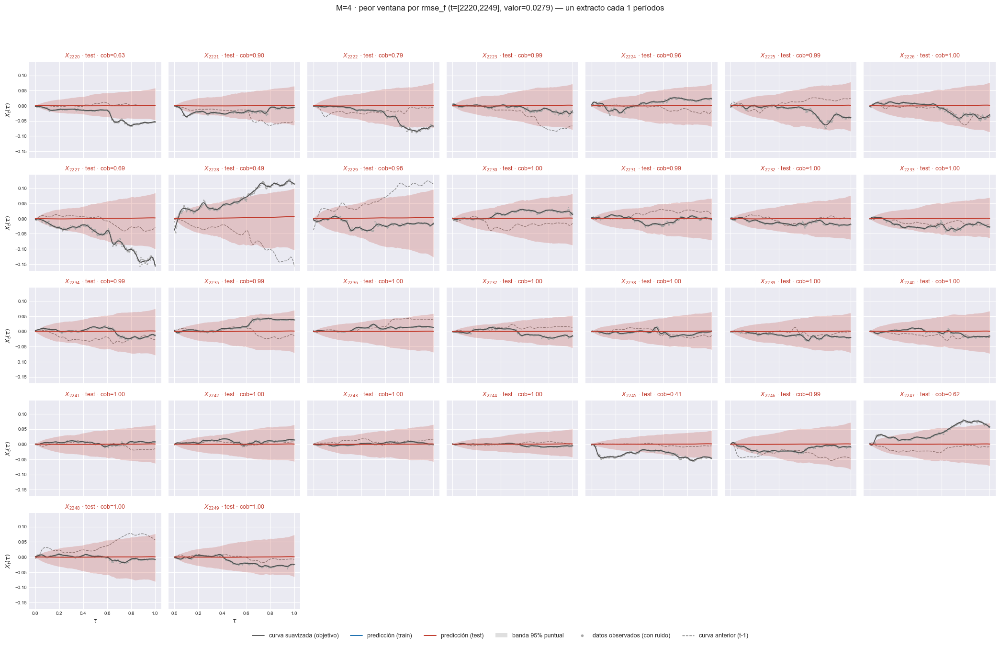

    t=[2227, 2256]  rmse_f=0.027674


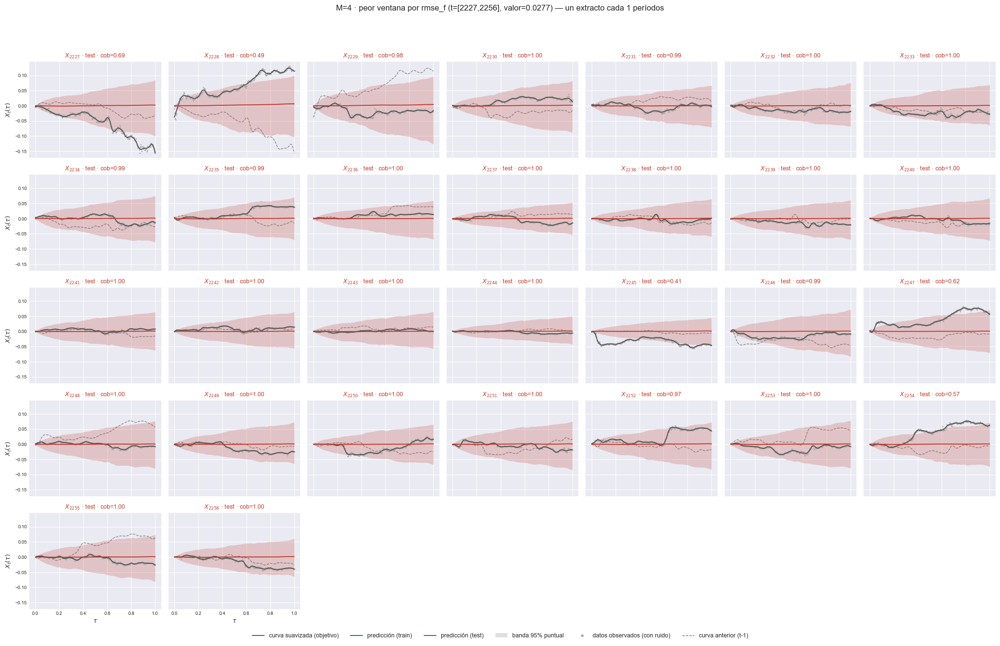

    t=[2219, 2248]  rmse_f=0.027634


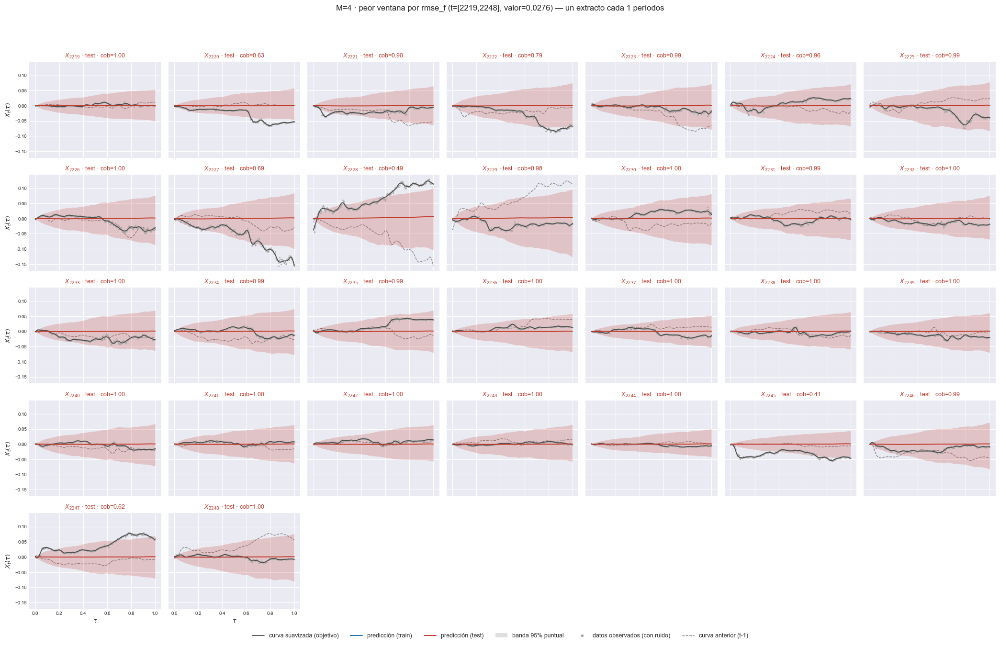

    t=[2218, 2247]  rmse_f=0.027613


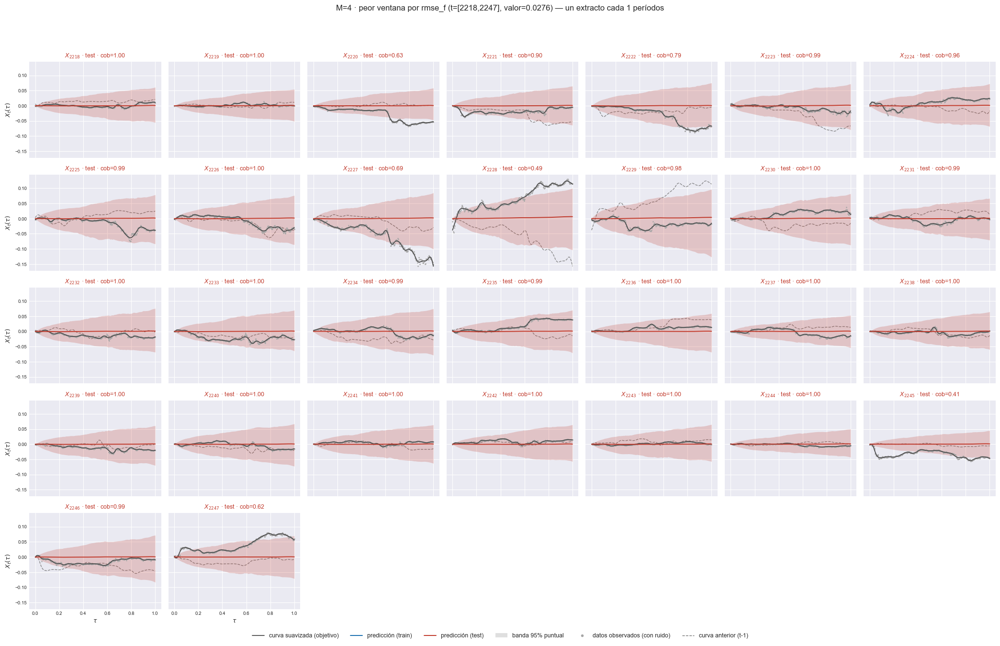

In [12]:
# Peores ventanas de test, con la curva anterior (t-1) al lado.
X_prev_full = np.full_like(X_obj_ev, np.nan)
X_prev_full[1:] = X_obj_ev[:-1]

for M in M_OK:
    e = EST[M]
    peores = peores_ventanas(e, W_REF, METRICA_PEORES, N_PEORES)
    print(f"[M={M}] peores {len(peores)} ventanas por {METRICA_PEORES} (w={W_REF}, test, sin cruzar T0)")
    for _, row in peores.iterrows():
        ini, fin = int(row["t_ini"]), int(row["t_fin"])
        print(f"    t=[{ini}, {fin}]  {METRICA_PEORES}={row[METRICA_PEORES]:.6f}")
        sel = np.where((t_orig >= ini) & (t_orig <= fin))[0]
        if sel.size == 0:
            continue
        plot_extractos_curvas(
            X_obj_ev[sel], e["X_pred"][sel], e["li_f"][sel], e["ls_f"][sel], grilla, T0,
            t=t_orig[sel], cada=1, n_col=min(len(sel), 7), nivel=NIVEL,
            etiqueta_objetivo="curva suavizada (objetivo)", X_obs=X_obs_ev[sel],
            X_prev=X_prev_full[sel],
            title=f"M={M} · peor ventana por {METRICA_PEORES} (t=[{ini},{fin}], "
                  f"valor={row[METRICA_PEORES]:.4f})",
            save_path=str(e["paths"]["out_report"] / f"56b_peor_ventana_{METRICA_PEORES}_t{ini}.png"),
            verbose=False)
        plt.show()

## 7. Probabilidades posteriores de inclusión (PIP)

Qué rezagos propios selecciona el modelo en cada componente. Con datos reales no hay estructura verdadera contra la cual contrastar: se reporta el PIP global y su dispersión entre cadenas.


In [13]:
for M in M_OK:
    pip_df = pip_punto(EST[M], SD_PIP_MAX)
    display(pip_df.style
        .background_gradient(subset=[c for c in pip_df.columns if not c.endswith("_sd")],
                             cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.3f}")
        .set_caption(f"M={M} · P(gamma_j = 1 | datos), inclusión global, media entre cadenas ± sd"))

[matriz_pip] inicio (1 pasos)
  1/1 (100.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 8 variables, PIP en [0.039, 1.000]
[matriz_pip] listo: 1 pasos en 0.0s  tabla 8x2
[M=1] dispersion maxima entre cadenas: 0.335   ! las cadenas discrepan sobre la seleccion


,FPC 1,FPC 1_sd
variable,,
fpc_1_lag1,0.118,0.135
fpc_1_lag2,0.039,0.004
fpc_1_lag3,0.271,0.314
fpc_1_lag4,0.142,0.143
fpc_1_lag5,0.078,0.049
fpc_1_lag6,0.286,0.335
fpc_1_lag7,0.070,0.014
logvr_lag1,1.000,0.000


[matriz_pip] inicio (2 pasos)
  1/2 (50.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 8 variables, PIP en [0.039, 1.000]
  2/2 (100.0%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 8 variables, PIP en [0.053, 1.000]
[matriz_pip] listo: 2 pasos en 0.0s  tabla 15x4
[M=2] dispersion maxima entre cadenas: 0.592   ! las cadenas discrepan sobre la seleccion


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd
variable,,,,
fpc_1_lag1,0.118,0.135,nan,nan
fpc_1_lag2,0.039,0.004,nan,nan
fpc_1_lag3,0.271,0.314,nan,nan
fpc_1_lag4,0.142,0.143,nan,nan
fpc_1_lag5,0.078,0.049,nan,nan
fpc_1_lag6,0.286,0.335,nan,nan
fpc_1_lag7,0.070,0.014,nan,nan
fpc_2_lag1,nan,nan,0.454,0.592
fpc_2_lag2,nan,nan,0.058,0.007


[matriz_pip] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 8 variables, PIP en [0.039, 1.000]
  2/3 (66.7%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 8 variables, PIP en [0.053, 1.000]
  3/3 (100.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 8 variables, PIP en [0.041, 1.000]
[matriz_pip] listo: 3 pasos en 0.0s  tabla 22x6
[M=3] dispersion maxima entre cadenas: 0.666   ! las cadenas discrepan sobre la seleccion


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd
variable,,,,,,
fpc_1_lag1,0.118,0.135,nan,nan,nan,nan
fpc_1_lag2,0.039,0.004,nan,nan,nan,nan
fpc_1_lag3,0.271,0.314,nan,nan,nan,nan
fpc_1_lag4,0.142,0.143,nan,nan,nan,nan
fpc_1_lag5,0.078,0.049,nan,nan,nan,nan
fpc_1_lag6,0.286,0.335,nan,nan,nan,nan
fpc_1_lag7,0.070,0.014,nan,nan,nan,nan
fpc_2_lag1,nan,nan,0.454,0.592,nan,nan
fpc_2_lag2,nan,nan,0.058,0.007,nan,nan


[matriz_pip] inicio (4 pasos)
  1/4 (25.0%) t=0.0s eta=0.0s  FPC 1: 2 cadenas, 8 variables, PIP en [0.039, 1.000]
  2/4 (50.0%) t=0.0s eta=0.0s  FPC 2: 2 cadenas, 8 variables, PIP en [0.053, 1.000]
  3/4 (75.0%) t=0.0s eta=0.0s  FPC 3: 2 cadenas, 8 variables, PIP en [0.041, 1.000]
  4/4 (100.0%) t=0.0s eta=0.0s  FPC 4: 2 cadenas, 8 variables, PIP en [0.023, 1.000]
[matriz_pip] listo: 4 pasos en 0.0s  tabla 29x8
[M=4] dispersion maxima entre cadenas: 0.666   ! las cadenas discrepan sobre la seleccion


,FPC 1,FPC 1_sd,FPC 2,FPC 2_sd,FPC 3,FPC 3_sd,FPC 4,FPC 4_sd
variable,,,,,,,,
fpc_1_lag1,0.118,0.135,nan,nan,nan,nan,nan,nan
fpc_1_lag2,0.039,0.004,nan,nan,nan,nan,nan,nan
fpc_1_lag3,0.271,0.314,nan,nan,nan,nan,nan,nan
fpc_1_lag4,0.142,0.143,nan,nan,nan,nan,nan,nan
fpc_1_lag5,0.078,0.049,nan,nan,nan,nan,nan,nan
fpc_1_lag6,0.286,0.335,nan,nan,nan,nan,nan,nan
fpc_1_lag7,0.070,0.014,nan,nan,nan,nan,nan,nan
fpc_2_lag1,nan,nan,0.454,0.592,nan,nan,nan,nan
fpc_2_lag2,nan,nan,0.058,0.007,nan,nan,nan,nan


## 8. Cuadro resumen: mínimo, máximo y promedio

La ventana móvil genera una SERIE por métrica, no una cifra. Esta tabla es la
lectura resumida de esa serie: mínimo, máximo y promedio, por bloque
train/test, excluyendo las ventanas que cruzan $T_0$ -su cifra mezcla dentro y
fuera de muestra-. Cubre las 7 métricas de los Bloques A y B; ninguna se
destaca sobre las demás.

In [14]:
# Los dos objetivos en la misma tabla, con la columna que declara cuál.
for M in M_OK:
    resumen = resumen_metricas(EST[M], M, DIS, ORIG)
    display(resumen.style.format({"minimo": "{:.6f}", "maximo": "{:.6f}", "promedio": "{:.6f}"})
            .set_caption(f"M={M} · mínimo / máximo / promedio por ventana "
                         f"(w={W_REF}, sin cruzar T0) · nivel funcional"))

resumen_bar = resumen_barrido(EST, M_OK, PATH_BARRIDO)
# Vista rápida: un solo objetivo (el primario del Bloque A); el CSV tiene los dos.
display(resumen_bar[(resumen_bar.bloque == "test") & (resumen_bar.objetivo == "curva_suavizada")]
        .pivot(index="metrica", columns="M", values="promedio").style.format("{:.6f}")
        .set_caption("Promedio en TEST contra M, objetivo=curva_suavizada (89_resumen_por_M.csv)"))

[M=1] curva_suavizada      PICP puntual test = 0.9340 (nominal 0.95)  ·  PICP simultaneo test = 0.2533
[M=1] representacion_fpca  PICP puntual test = 0.9775 (nominal 0.95)  ·  PICP simultaneo test = 0.9775


[M=2] curva_suavizada      PICP puntual test = 0.9586 (nominal 0.95)  ·  PICP simultaneo test = 0.4300
[M=2] representacion_fpca  PICP puntual test = 0.9767 (nominal 0.95)  ·  PICP simultaneo test = 0.9419


[M=3] curva_suavizada      PICP puntual test = 0.9656 (nominal 0.95)  ·  PICP simultaneo test = 0.4637
[M=3] representacion_fpca  PICP puntual test = 0.9751 (nominal 0.95)  ·  PICP simultaneo test = 0.9313


[M=4] curva_suavizada      PICP puntual test = 0.9670 (nominal 0.95)  ·  PICP simultaneo test = 0.4751
[M=4] representacion_fpca  PICP puntual test = 0.9750 (nominal 0.95)  ·  PICP simultaneo test = 0.9131


M,1,2,3,4
metrica,,,,
1. MAE (L^1),0.010291,0.010294,0.010293,0.010293
10. Winkler max peor ventana,1.124075,1.014067,0.983789,0.967250
2. RMSE (L^2),0.015080,0.015078,0.015077,0.015078
3. E_max promedio por curva,0.023604,0.023593,0.023597,0.023595
4. E_max peor de la ventana,0.067298,0.067306,0.067295,0.067300
5. MPIW,0.063831,0.068860,0.070370,0.070937
6. PICP puntual,0.933966,0.958579,0.965583,0.966962
7. PICPB curva completa,0.253276,0.430009,0.463675,0.475071
8. Winkler,0.082673,0.082494,0.082655,0.082871


## 9. Monitoreo univariado por componente FPCA

Cada componente FPCA retenida se predice de manera univariada dentro del
modelo -es una mezcla por componente-, así que aquí se mira su MAE, RMSE y
MISE (= RMSE² del score, el análogo puntual del MISE funcional) por separado,
sobre la ventana móvil. Con $M=1$ hay una sola línea por panel; con $M=k$ hay
$k$ líneas, una por componente. **Solo monitoreo**: ninguna de las tres es
primaria.

[ventana_movil_scores[FPC 1, w=30]] inicio (2398 pasos)
  1/2398 ( 0.0%) t=0.0s eta=5.3s  t=22 [train] rmse=0.0165
  119/2398 ( 5.0%) t=0.0s eta=0.8s  t=140 [train] rmse=0.02482
  238/2398 ( 9.9%) t=0.1s eta=0.8s  t=259 [train] rmse=0.01614
  357/2398 (14.9%) t=0.1s eta=0.6s  t=378 [train] rmse=0.03869
  476/2398 (19.8%) t=0.1s eta=0.6s  t=497 [train] rmse=0.03767
  595/2398 (24.8%) t=0.2s eta=0.5s  t=616 [train] rmse=0.02397
  714/2398 (29.8%) t=0.2s eta=0.5s  t=735 [train] rmse=0.01247
  833/2398 (34.7%) t=0.2s eta=0.4s  t=854 [train] rmse=0.0231
  952/2398 (39.7%) t=0.2s eta=0.4s  t=973 [train] rmse=0.02328
  1071/2398 (44.7%) t=0.3s eta=0.3s  t=1092 [train] rmse=0.008514
  1190/2398 (49.6%) t=0.3s eta=0.3s  t=1211 [train] rmse=0.01383
  1309/2398 (54.6%) t=0.3s eta=0.3s  t=1330 [train] rmse=0.009701
  1428/2398 (59.5%) t=0.3s eta=0.2s  t=1449 [train] rmse=0.01447
  1547/2398 (64.5%) t=0.4s eta=0.2s  t=1568 [train] rmse=0.01651
  1666/2398 (69.5%) t=0.4s eta=0.2s  t=1687 [train] rms

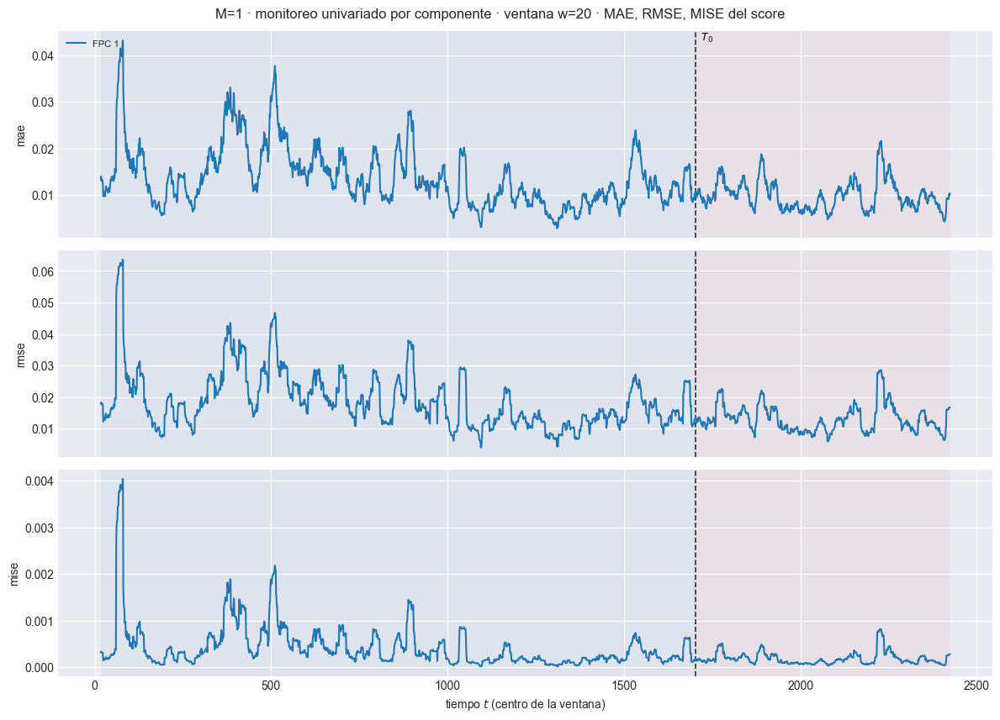

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  mae: w=30 train=0.01255  w=30 test=0.009376
  2/3 (66.7%) t=0.0s eta=0.0s  rmse: w=30 train=0.01722  w=30 test=0.01275
  3/3 (100.0%) t=0.0s eta=0.0s  mise: w=30 train=0.0002965  w=30 test=0.0001625
[plot_ventana_movil] listo: 3 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m01\91_ventana_univariado_w30.png


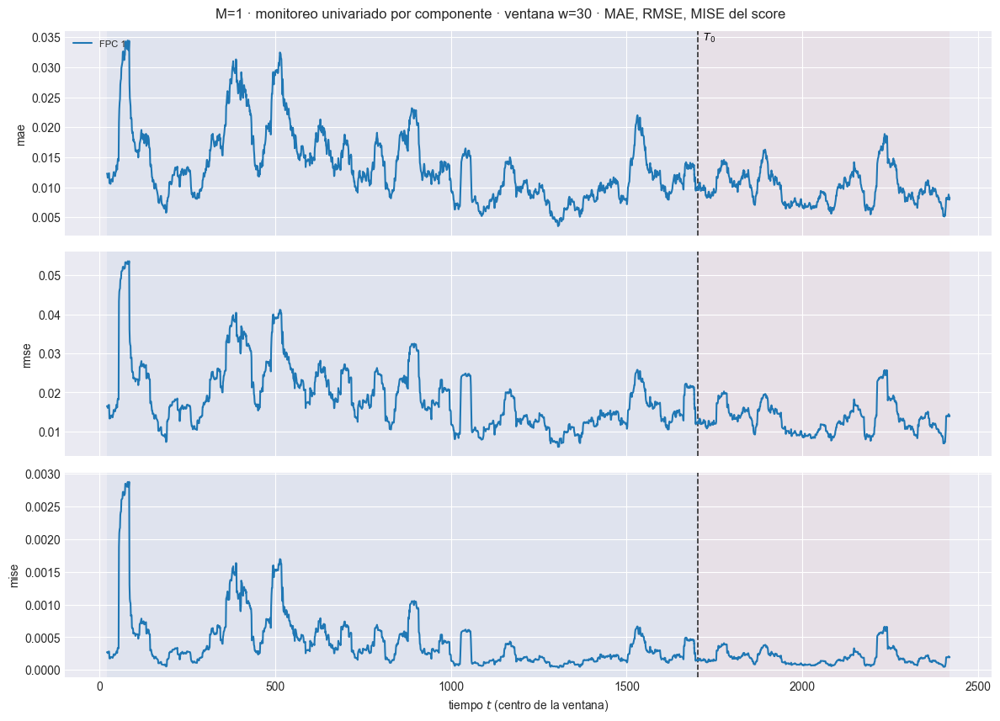

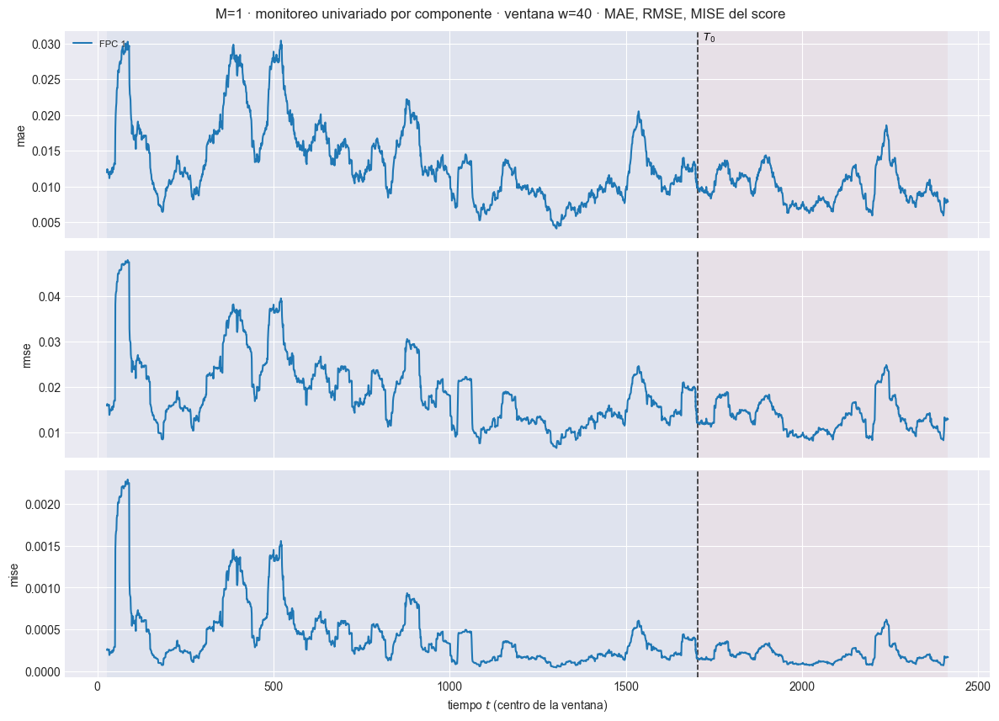

[ventana_movil_scores[FPC 1, w=30]] inicio (2398 pasos)
  1/2398 ( 0.0%) t=0.0s eta=3.1s  t=22 [train] rmse=0.0165
  119/2398 ( 5.0%) t=0.0s eta=0.5s  t=140 [train] rmse=0.02482
  238/2398 ( 9.9%) t=0.0s eta=0.4s  t=259 [train] rmse=0.01614
  357/2398 (14.9%) t=0.1s eta=0.4s  t=378 [train] rmse=0.03869
  476/2398 (19.8%) t=0.1s eta=0.4s  t=497 [train] rmse=0.03767
  595/2398 (24.8%) t=0.1s eta=0.3s  t=616 [train] rmse=0.02397
  714/2398 (29.8%) t=0.1s eta=0.3s  t=735 [train] rmse=0.01247
  833/2398 (34.7%) t=0.1s eta=0.3s  t=854 [train] rmse=0.0231
  952/2398 (39.7%) t=0.2s eta=0.2s  t=973 [train] rmse=0.02328
  1071/2398 (44.7%) t=0.2s eta=0.2s  t=1092 [train] rmse=0.008514
  1190/2398 (49.6%) t=0.2s eta=0.2s  t=1211 [train] rmse=0.01383
  1309/2398 (54.6%) t=0.2s eta=0.2s  t=1330 [train] rmse=0.009701
  1428/2398 (59.5%) t=0.2s eta=0.2s  t=1449 [train] rmse=0.01447
  1547/2398 (64.5%) t=0.2s eta=0.1s  t=1568 [train] rmse=0.01651
  1666/2398 (69.5%) t=0.3s eta=0.1s  t=1687 [train] rms

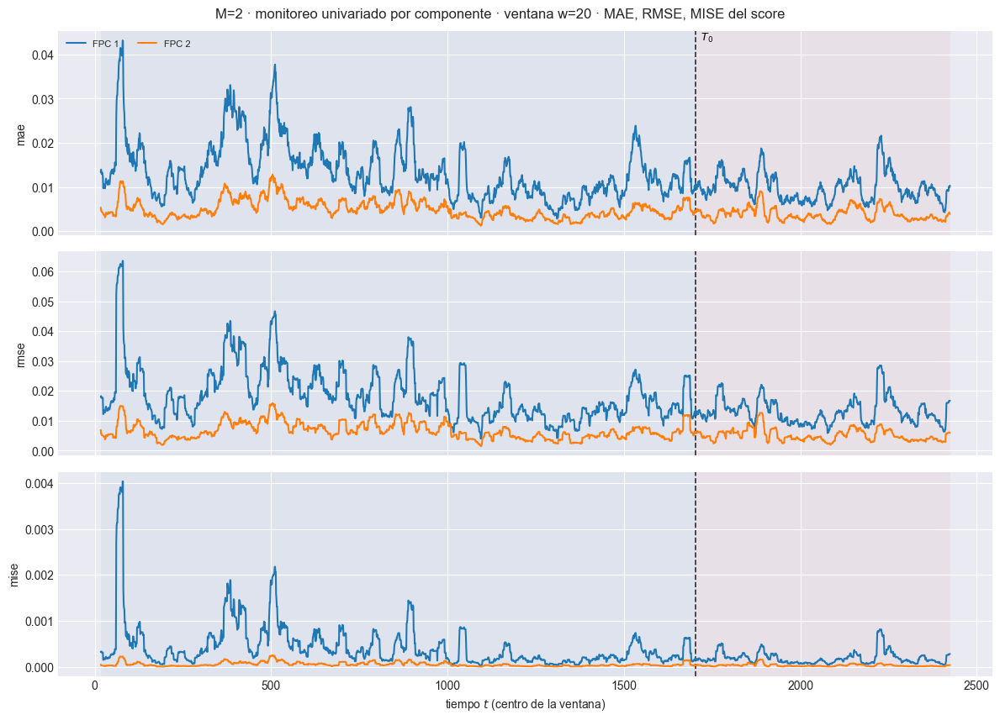

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.1s  mae: w=30 train=0.007516  w=30 test=0.006411
  2/3 (66.7%) t=0.1s eta=0.0s  rmse: w=30 train=0.0105  w=30 test=0.00853
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=30 train=0.0001103  w=30 test=7.276e-05
[plot_ventana_movil] listo: 3 pasos en 0.7s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m02\91_ventana_univariado_w30.png


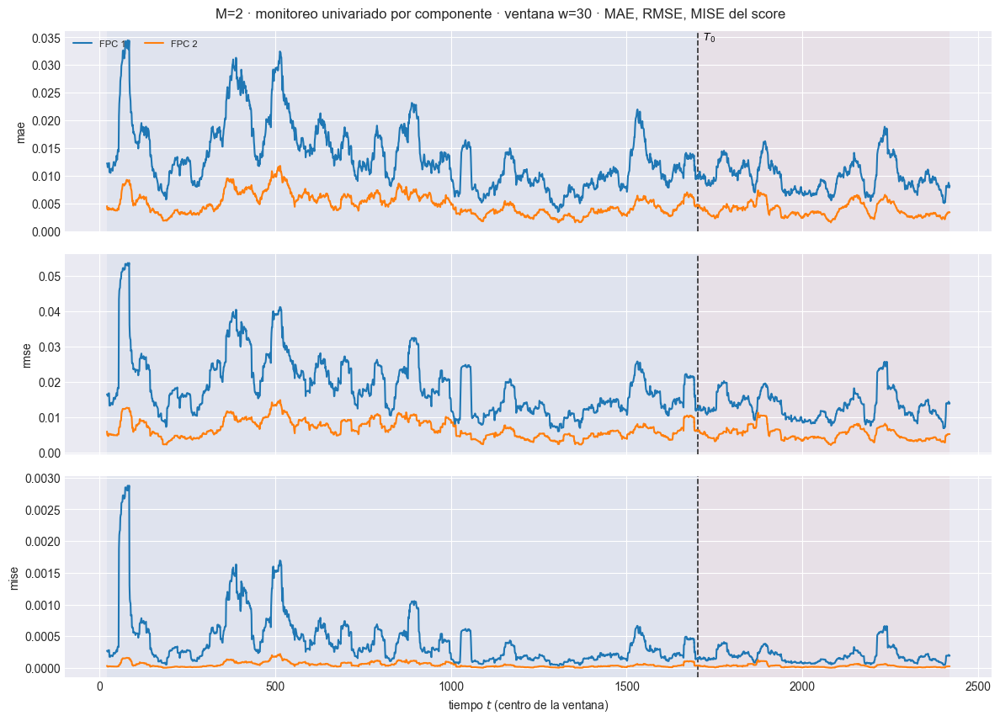

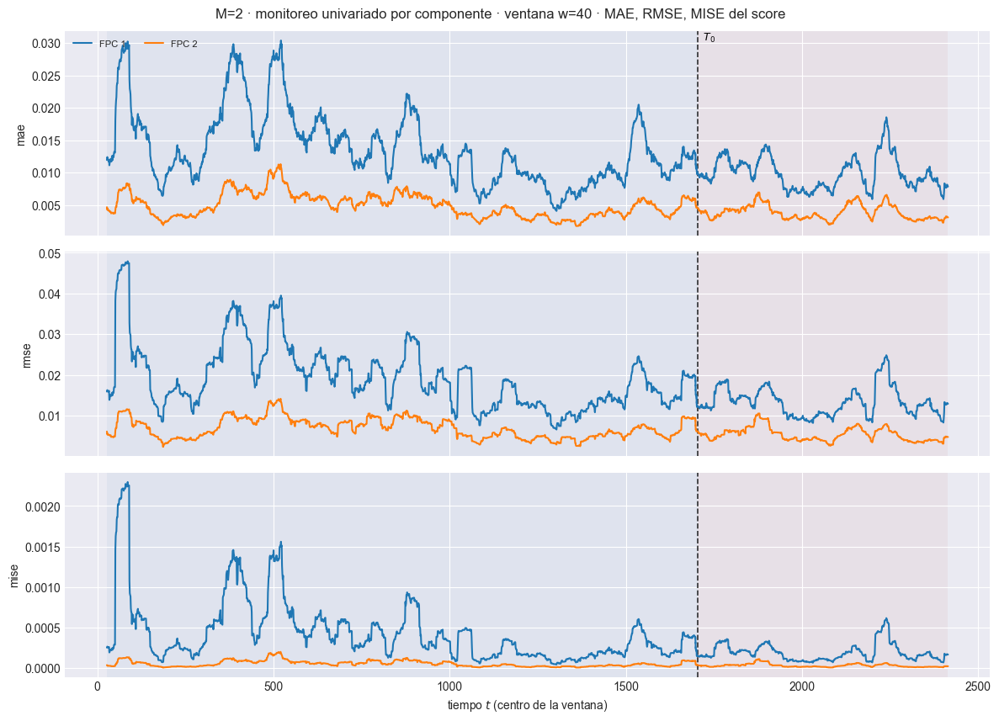

[ventana_movil_scores[FPC 1, w=30]] inicio (2398 pasos)
  1/2398 ( 0.0%) t=0.0s eta=3.4s  t=22 [train] rmse=0.0165
  119/2398 ( 5.0%) t=0.0s eta=0.4s  t=140 [train] rmse=0.02482
  238/2398 ( 9.9%) t=0.0s eta=0.4s  t=259 [train] rmse=0.01614
  357/2398 (14.9%) t=0.1s eta=0.4s  t=378 [train] rmse=0.03869
  476/2398 (19.8%) t=0.1s eta=0.4s  t=497 [train] rmse=0.03767
  595/2398 (24.8%) t=0.1s eta=0.4s  t=616 [train] rmse=0.02397
  714/2398 (29.8%) t=0.1s eta=0.3s  t=735 [train] rmse=0.01247
  833/2398 (34.7%) t=0.2s eta=0.3s  t=854 [train] rmse=0.0231
  952/2398 (39.7%) t=0.2s eta=0.3s  t=973 [train] rmse=0.02328
  1071/2398 (44.7%) t=0.2s eta=0.3s  t=1092 [train] rmse=0.008514
  1190/2398 (49.6%) t=0.2s eta=0.2s  t=1211 [train] rmse=0.01383
  1309/2398 (54.6%) t=0.2s eta=0.2s  t=1330 [train] rmse=0.009701
  1428/2398 (59.5%) t=0.3s eta=0.2s  t=1449 [train] rmse=0.01447
  1547/2398 (64.5%) t=0.3s eta=0.2s  t=1568 [train] rmse=0.01651
  1666/2398 (69.5%) t=0.3s eta=0.1s  t=1687 [train] rms

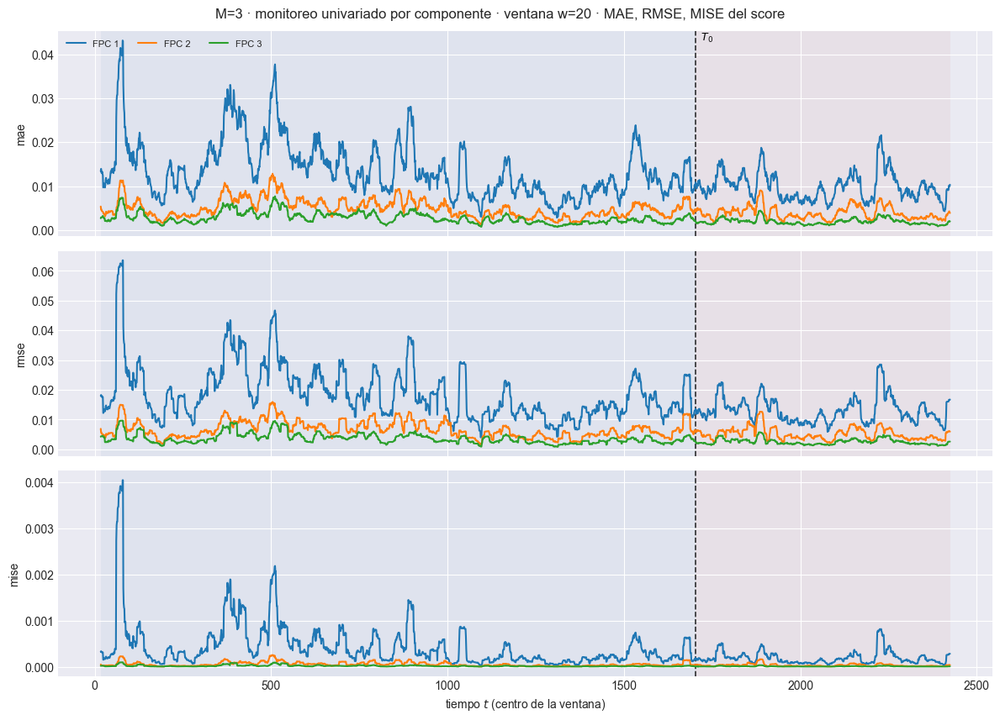

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.1s eta=0.1s  mae: w=30 train=0.00494  w=30 test=0.003542
  2/3 (66.7%) t=0.1s eta=0.0s  rmse: w=30 train=0.006969  w=30 test=0.004877
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=30 train=4.857e-05  w=30 test=2.379e-05
[plot_ventana_movil] listo: 3 pasos en 0.7s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m03\91_ventana_univariado_w30.png


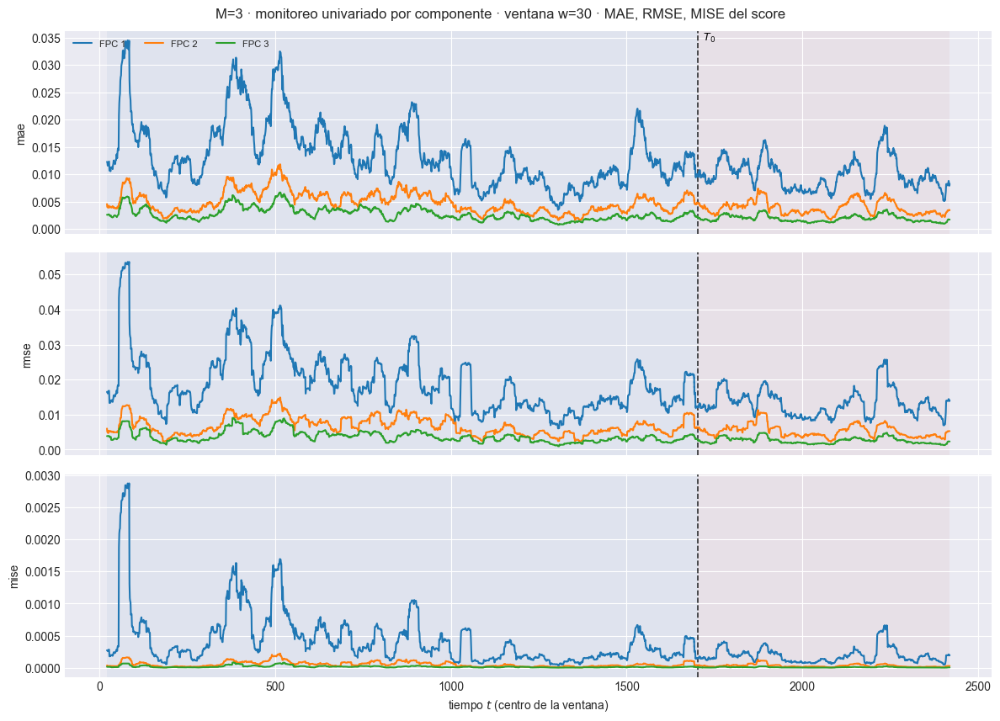

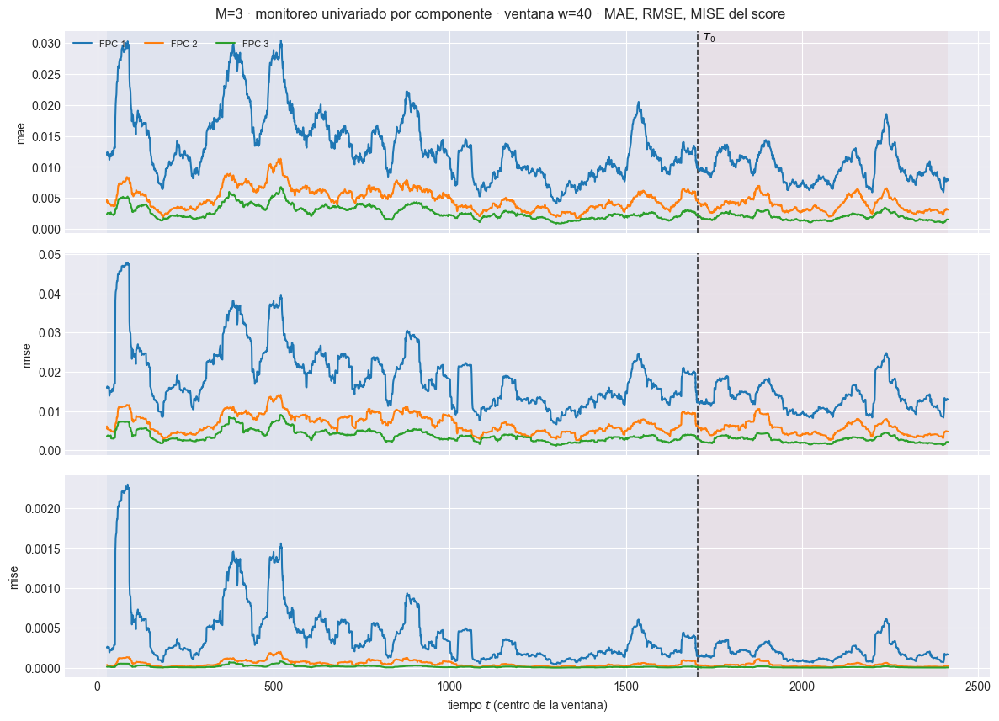

[ventana_movil_scores[FPC 1, w=30]] inicio (2398 pasos)
  1/2398 ( 0.0%) t=0.0s eta=3.7s  t=22 [train] rmse=0.0165
  119/2398 ( 5.0%) t=0.0s eta=0.4s  t=140 [train] rmse=0.02482
  238/2398 ( 9.9%) t=0.0s eta=0.4s  t=259 [train] rmse=0.01614
  357/2398 (14.9%) t=0.1s eta=0.4s  t=378 [train] rmse=0.03869
  476/2398 (19.8%) t=0.1s eta=0.3s  t=497 [train] rmse=0.03767
  595/2398 (24.8%) t=0.1s eta=0.3s  t=616 [train] rmse=0.02397
  714/2398 (29.8%) t=0.1s eta=0.3s  t=735 [train] rmse=0.01247
  833/2398 (34.7%) t=0.2s eta=0.3s  t=854 [train] rmse=0.0231
  952/2398 (39.7%) t=0.2s eta=0.3s  t=973 [train] rmse=0.02328
  1071/2398 (44.7%) t=0.2s eta=0.3s  t=1092 [train] rmse=0.008514
  1190/2398 (49.6%) t=0.2s eta=0.2s  t=1211 [train] rmse=0.01383
  1309/2398 (54.6%) t=0.3s eta=0.2s  t=1330 [train] rmse=0.009701
  1428/2398 (59.5%) t=0.3s eta=0.2s  t=1449 [train] rmse=0.01447
  1547/2398 (64.5%) t=0.3s eta=0.2s  t=1568 [train] rmse=0.01651
  1666/2398 (69.5%) t=0.3s eta=0.1s  t=1687 [train] rms

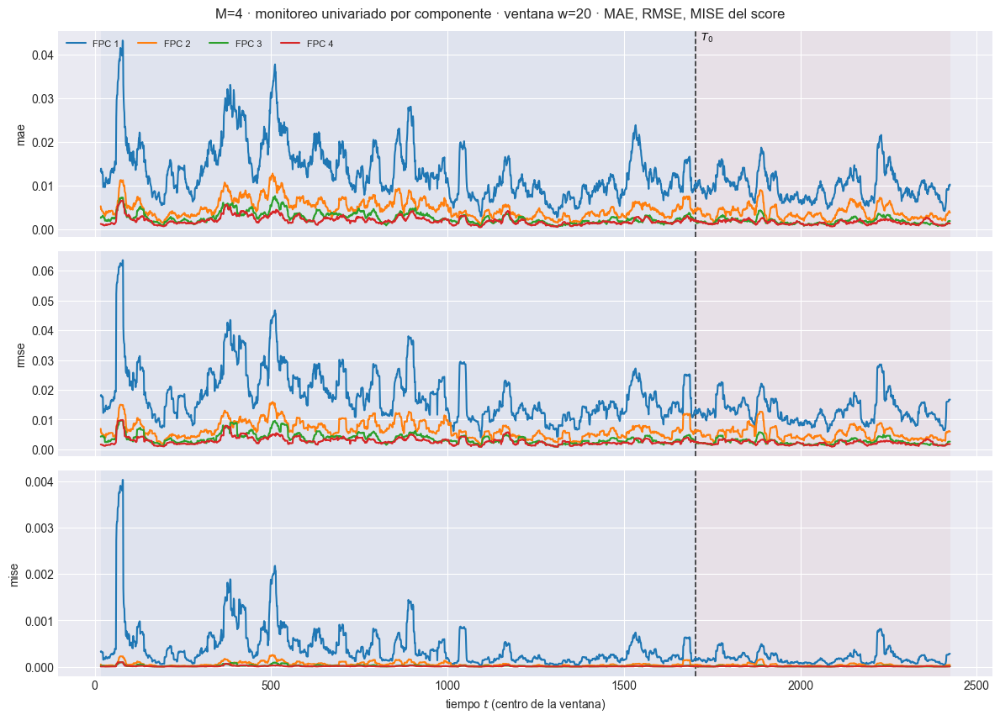

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.1s  mae: w=30 train=0.003607  w=30 test=0.002622
  2/3 (66.7%) t=0.1s eta=0.0s  rmse: w=30 train=0.004868  w=30 test=0.003565
  3/3 (100.0%) t=0.1s eta=0.0s  mise: w=30 train=2.37e-05  w=30 test=1.271e-05
[plot_ventana_movil] listo: 3 pasos en 0.7s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m04\91_ventana_univariado_w30.png


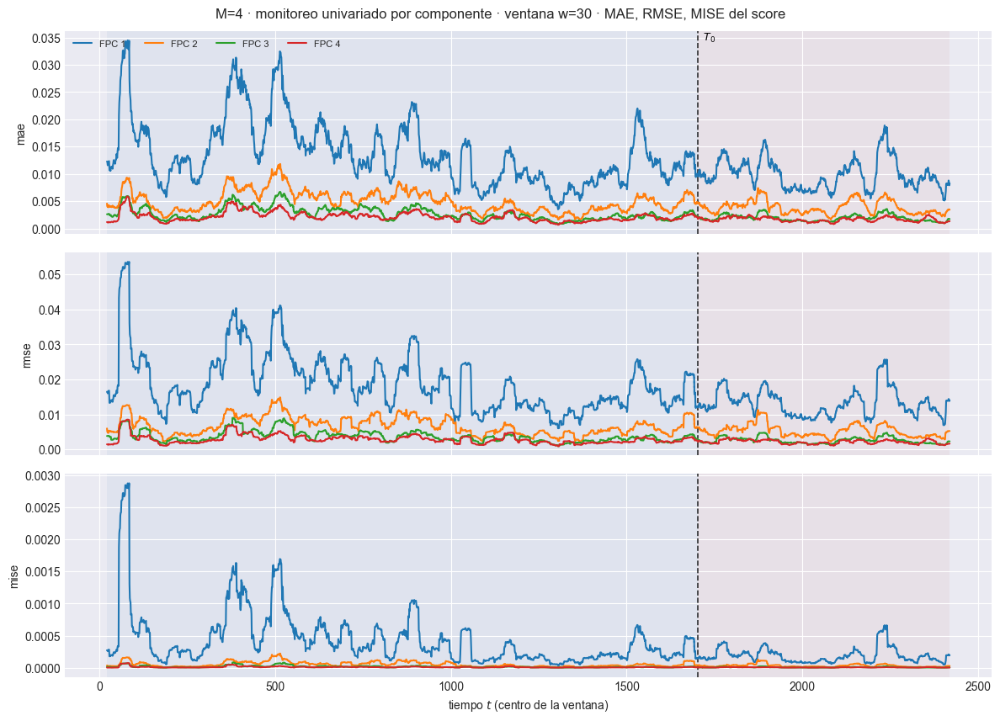

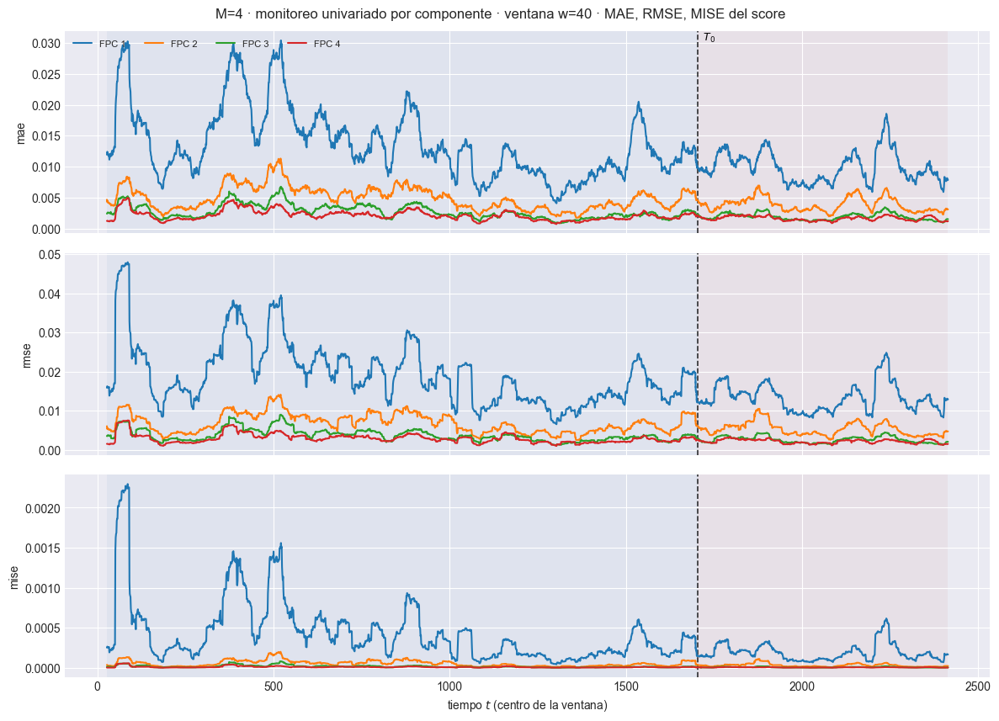

In [15]:
for M in M_OK:
    e = EST[M]
    monitoreo_scores(e, DIS, ORIG)
    for w in VENTANAS_W:
        tsc = e["tablas_score"][w].copy()
        tsc["mise"] = tsc["rmse"] ** 2      # MSE del score: análogo puntual del MISE
        plot_ventana_movil(
            tsc, T0, ["mae", "rmse", "mise"], columna_grupo="componente",
            title=f"M={M} · monitoreo univariado por componente · ventana w={w} · MAE, RMSE, MISE del score",
            save_path=str(e["paths"]["out_report"] / f"91_ventana_univariado_w{w}.png"),
            verbose=(w == W_REF))
        plt.show()

## 10. Evaluación puntual de los scores (coeficientes FPCA)

Las secciones anteriores miran la **curva**, que es el producto final. Ésta
mira el objeto que el muestreador predice de verdad: el score $\xi_{t,k}$ de
cada componente. La curva sale de propagarlos, así que un problema de
calibración que aquí se vea localizado en una componente queda, allá,
promediado con las demás y es mucho más difícil de atribuir.

| | qué muestra |
|---|---|
| **§10.1** | el intervalo de credibilidad de cada $\xi_k$ a lo largo del tiempo, con $\xi$ observado encima |
| **§10.2** | las métricas de ese intervalo: PICP, MPIW, Winkler, ACE — globales por bloque y sobre la ventana móvil, un panel por ancho |
| **§10.3** | dispersión $\hat\xi$ contra $\xi$ con la diagonal, componente a componente |

La banda es `li_s`/`ls_s`, los cuantiles muestrales de la predictiva por score
que §3 ya calculó: es **la misma** de la que sale la banda funcional, antes de
propagarla. No se vuelve a muestrear nada.


### 10.1 Cómo se mueve el intervalo de credibilidad de cada score

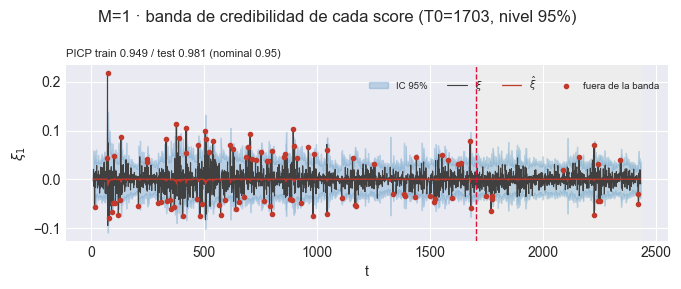

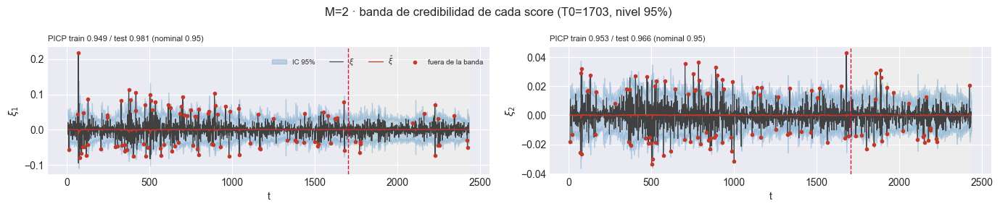

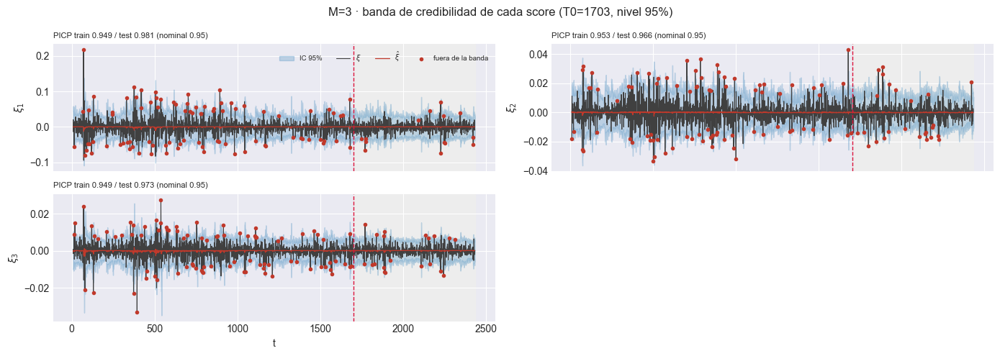

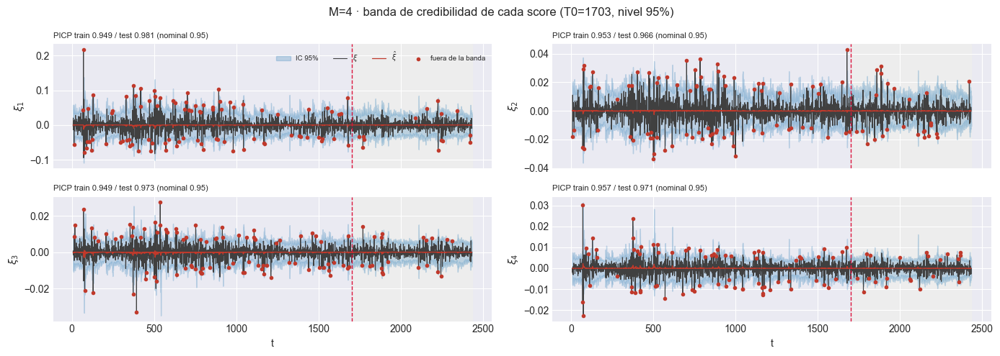

In [16]:
for M in M_OK:
    plot_scores_banda(EST[M], ORIG, DIS, M,
                      save_path=EST[M]["paths"]["out_report"] / "92_scores_banda_credibilidad.png")
    plt.show()

### 10.2 Métricas de intervalo sobre los scores

Las mismas cuatro cifras del Bloque B, pero por componente y en la escala del
score: **PICP** (fracción de orígenes cubiertos), **MPIW** (ancho medio),
**Winkler** (regla de puntuación que penaliza ancho y fallo a la vez) y
**ACE** = PICP − nominal, que es el signo de la miscalibración: negativo es
subcobertura.

Primero la lectura global por bloque; después la evolución sobre la ventana
móvil, **un panel por ancho**, con el mismo criterio de §4 y §5.


OK ninguna componente se aleja mas de 0.1 del nominal en test.


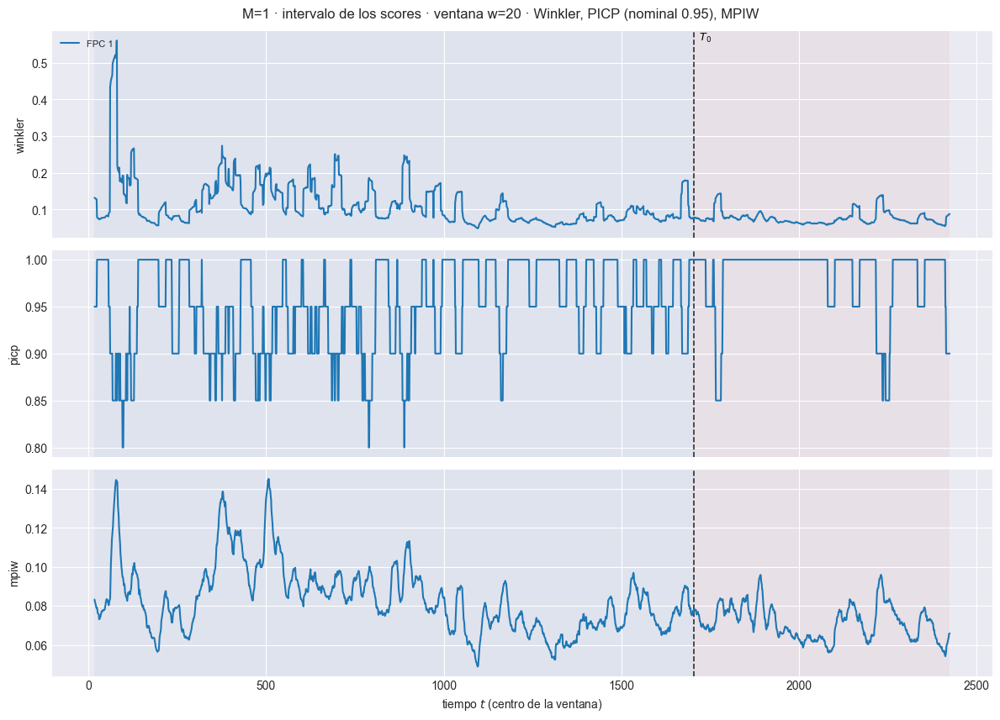

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  winkler: w=30 train=0.09949  w=30 test=0.07343
  2/3 (66.7%) t=0.0s eta=0.0s  picp: w=30 train=0.9333  w=30 test=1
  3/3 (100.0%) t=0.0s eta=0.0s  mpiw: w=30 train=0.08215  w=30 test=0.07147
[plot_ventana_movil] listo: 3 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m01\93_ventana_scores_intervalo_w30.png


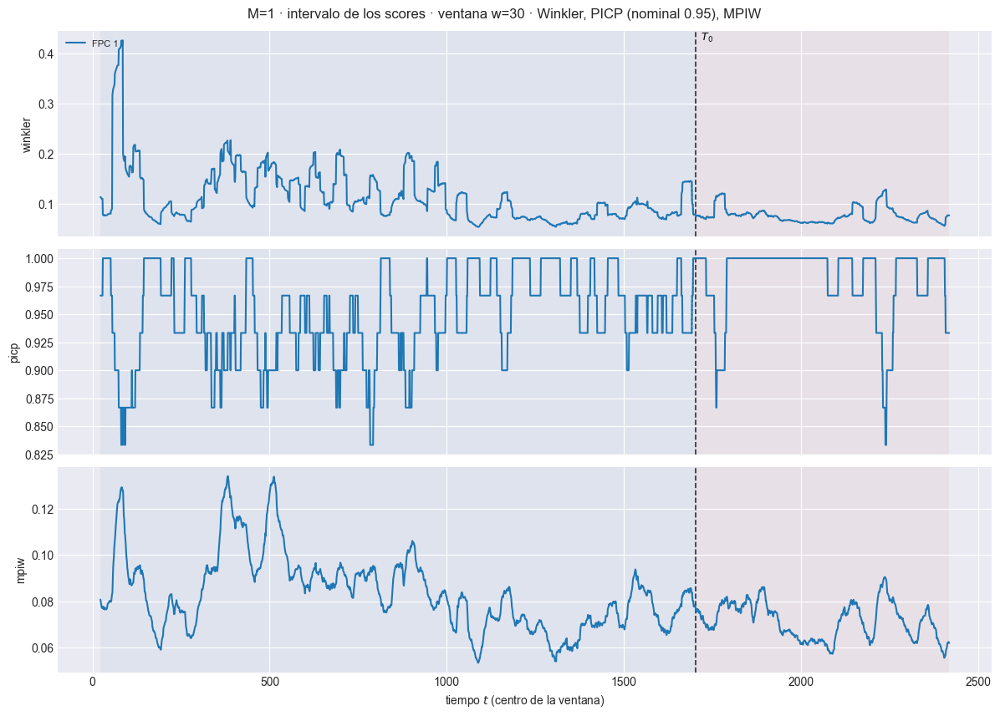

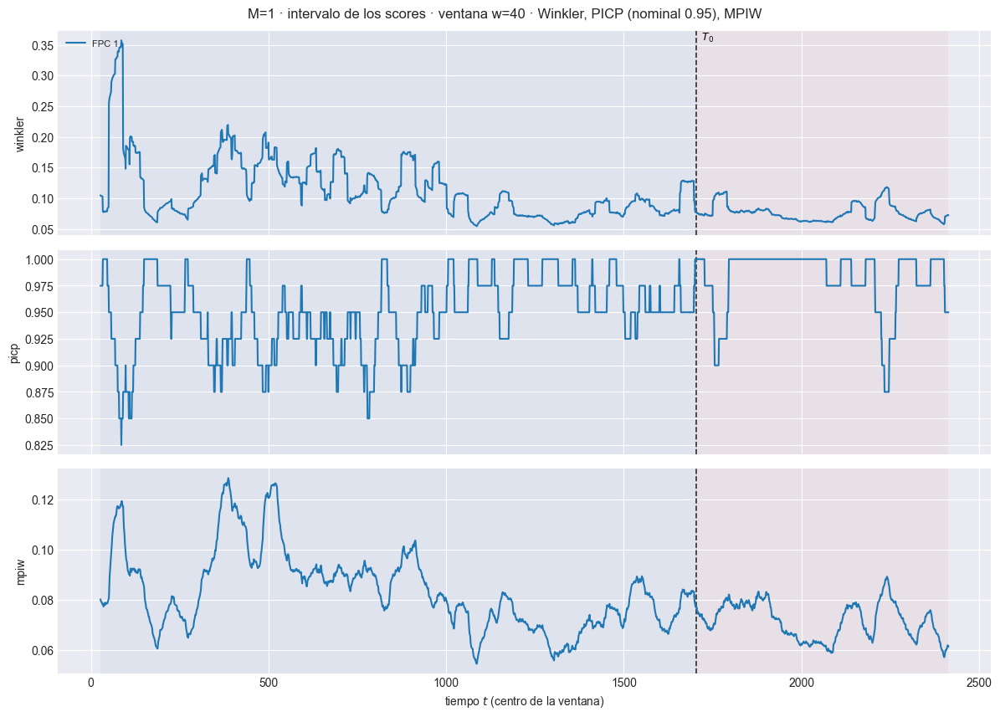

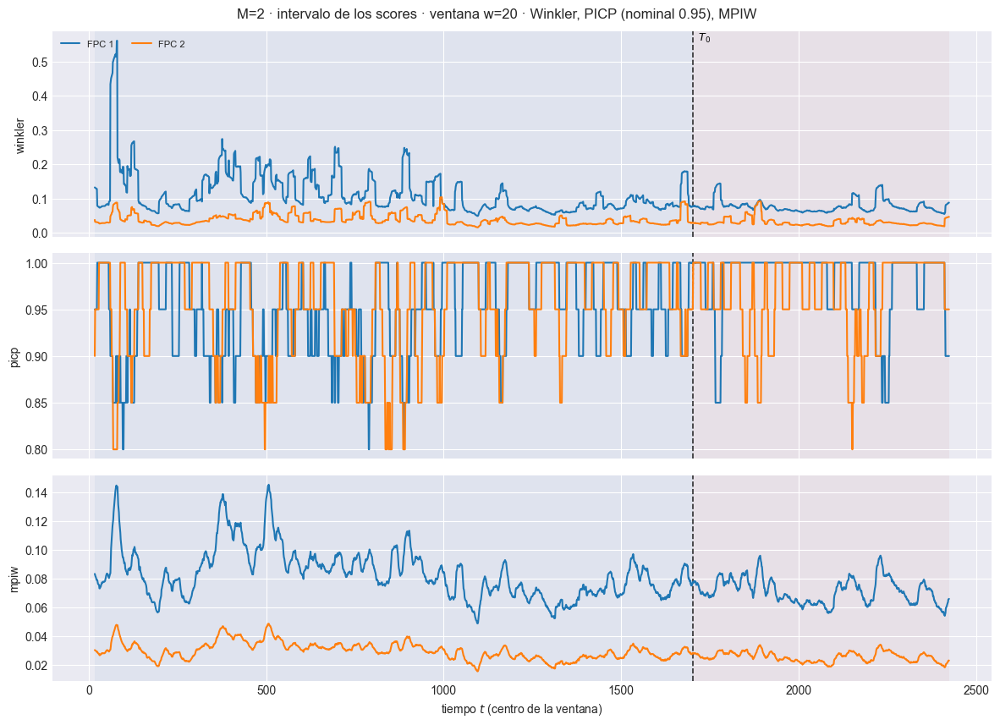

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  winkler: w=30 train=0.06375  w=30 test=0.06114
  2/3 (66.7%) t=0.0s eta=0.0s  picp: w=30 train=0.9667  w=30 test=1
  3/3 (100.0%) t=0.1s eta=0.0s  mpiw: w=30 train=0.04952  w=30 test=0.04402
[plot_ventana_movil] listo: 3 pasos en 0.5s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m02\93_ventana_scores_intervalo_w30.png


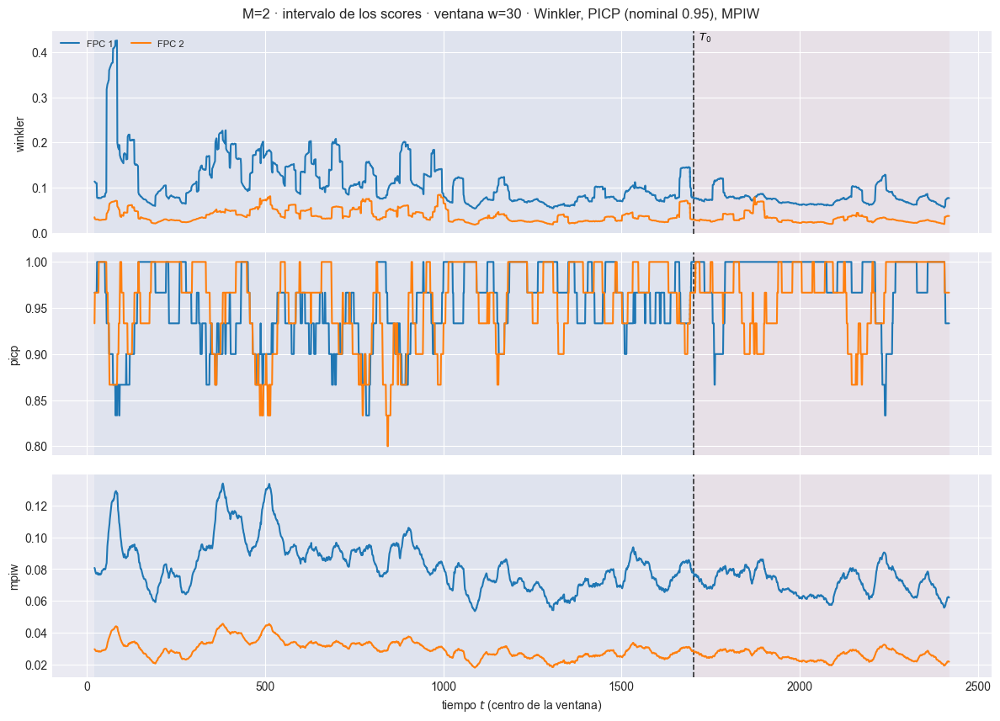

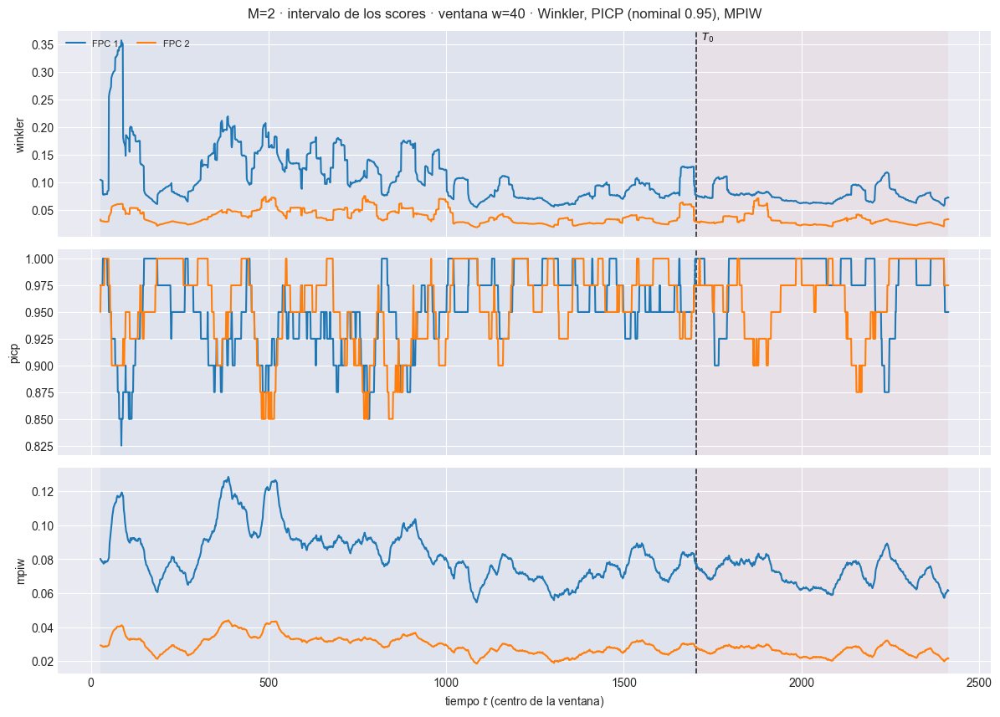

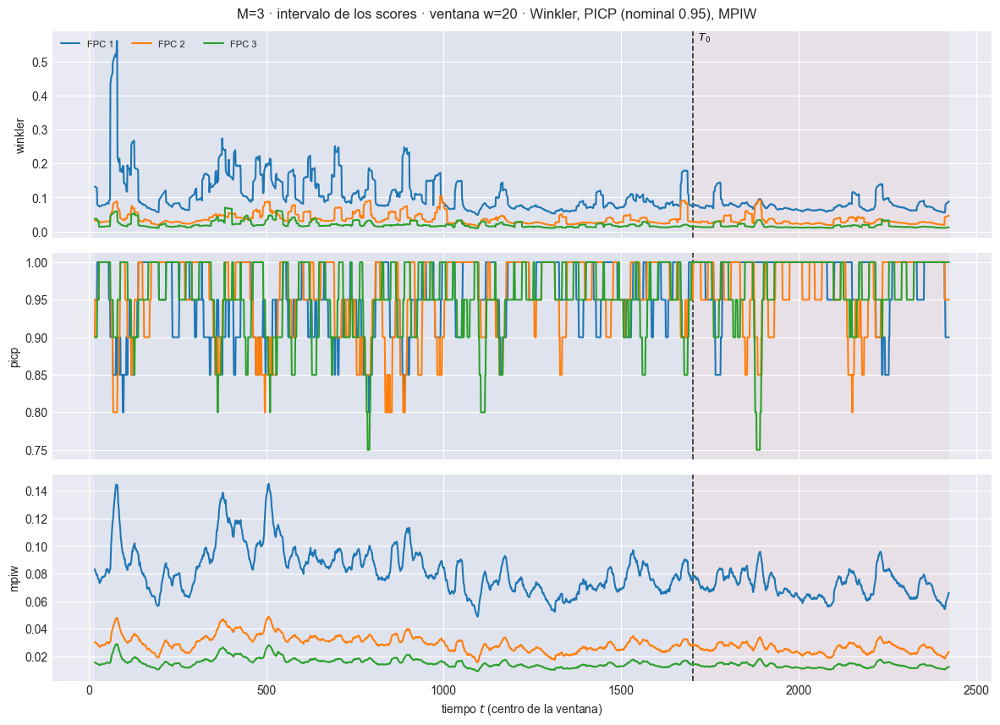

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.0s  winkler: w=30 train=0.0375  w=30 test=0.02781
  2/3 (66.7%) t=0.0s eta=0.0s  picp: w=30 train=0.9667  w=30 test=1
  3/3 (100.0%) t=0.1s eta=0.0s  mpiw: w=30 train=0.02981  w=30 test=0.02568
[plot_ventana_movil] listo: 3 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m03\93_ventana_scores_intervalo_w30.png


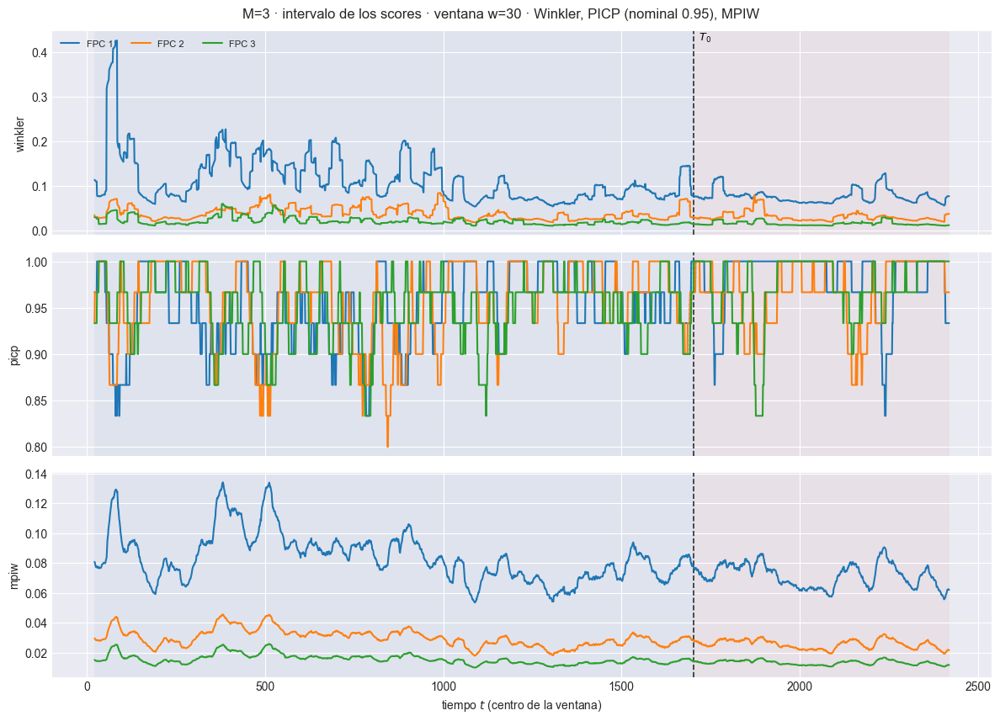

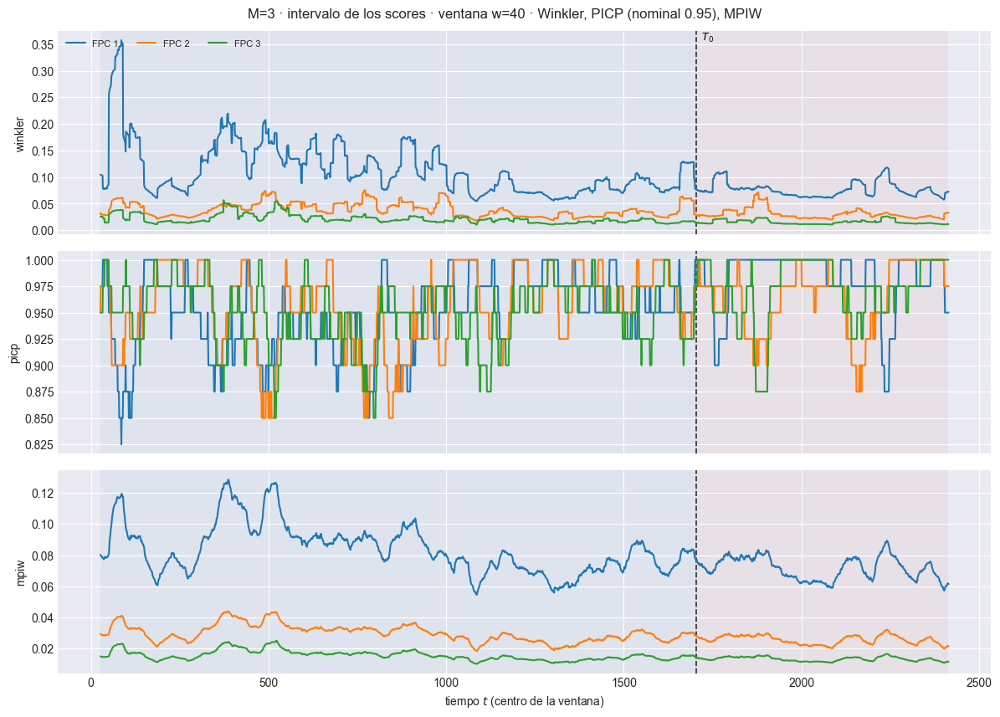

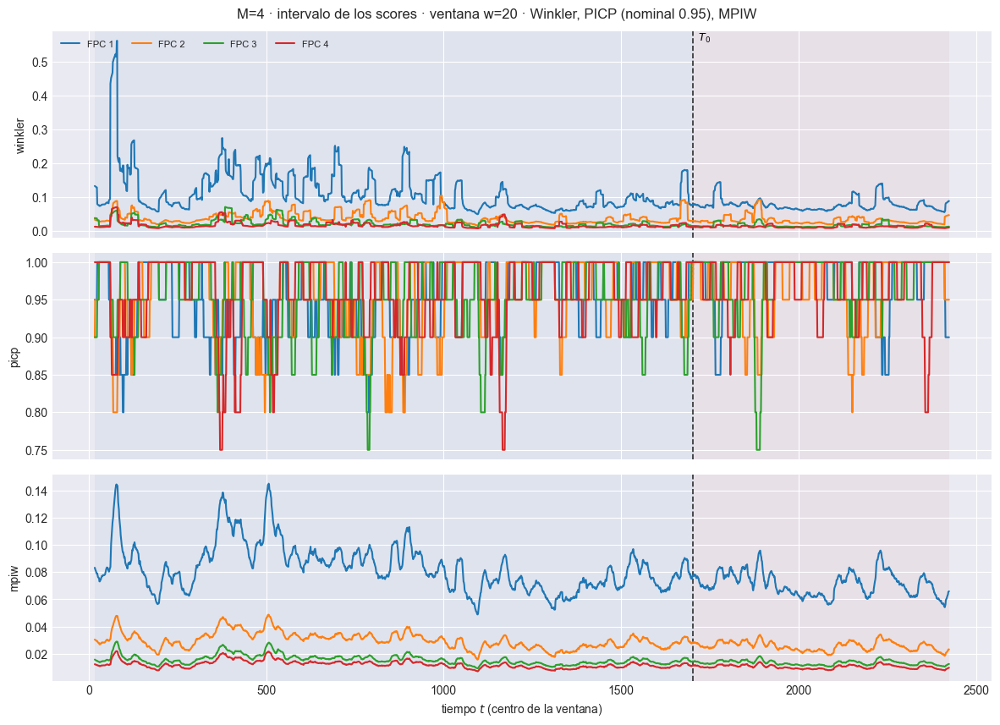

[plot_ventana_movil] inicio (3 pasos)
  1/3 (33.3%) t=0.0s eta=0.1s  winkler: w=30 train=0.02746  w=30 test=0.02269
  2/3 (66.7%) t=0.1s eta=0.0s  picp: w=30 train=0.9667  w=30 test=0.9667
  3/3 (100.0%) t=0.1s eta=0.0s  mpiw: w=30 train=0.02155  w=30 test=0.01792
[plot_ventana_movil] listo: 3 pasos en 0.6s  -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_vr_v01_m04\93_ventana_scores_intervalo_w30.png


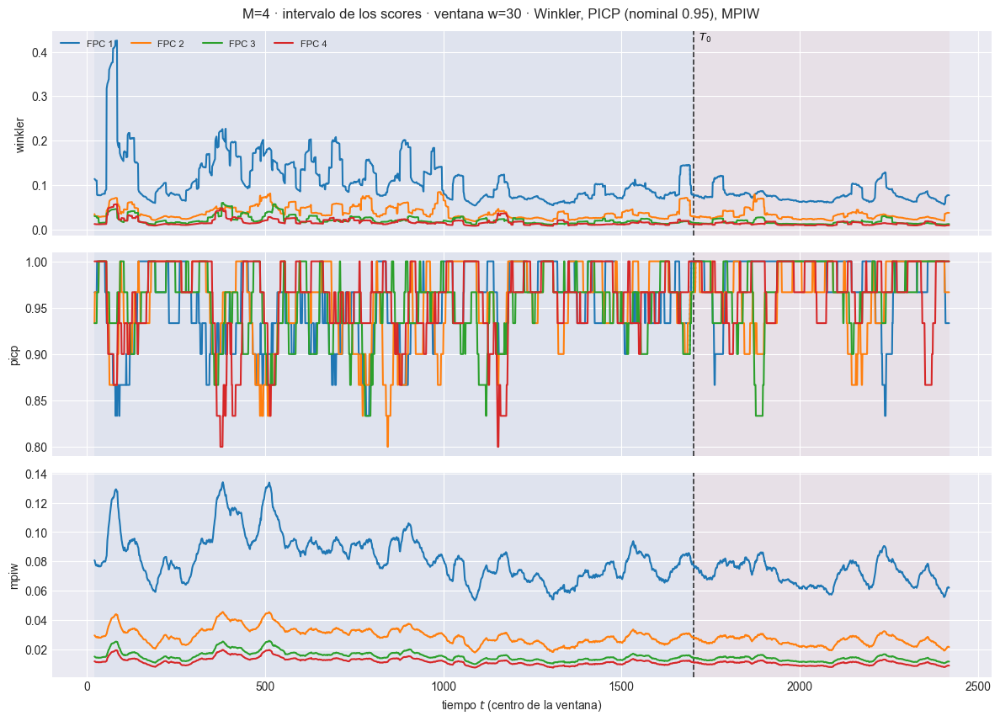

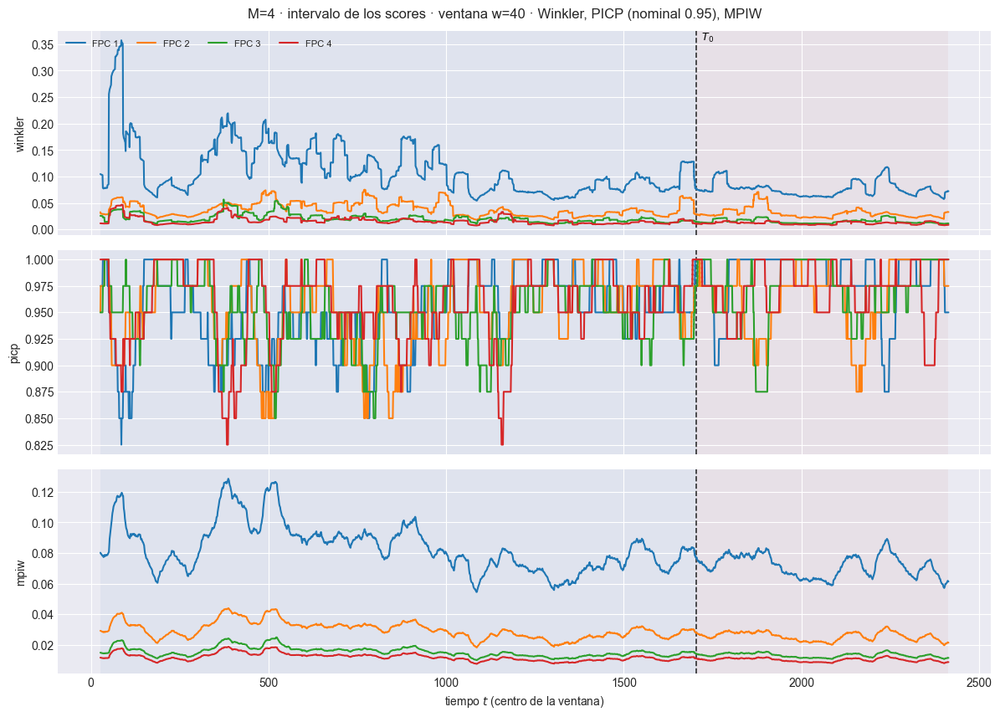

In [17]:
INT_SCORES = intervalos_scores(EST, M_OK, DIS, ORIG, PATH_BARRIDO)
display(INT_SCORES.set_index(["M", "componente", "bloque"]).style
        .format({"picp": "{:.4f}", "ace": "{:+.4f}", "mpiw": "{:.4f}", "winkler": "{:.4f}",
                 "sd_banda": "{:.4f}", "rmse": "{:.4f}", "mpiw_sobre_rmse": "{:.2f}"})
        .background_gradient(subset=["ace"], cmap="RdYlGn", vmin=-0.5, vmax=0.5)
        .set_caption(f"Intervalos de credibilidad de los scores, nivel {NIVEL:.0%} · ACE = PICP - nominal · "
                     "mpiw/rmse ≈ 3.92 si la banda fuera gaussiana y calibrada"))

# Evolución del intervalo sobre la ventana móvil, una figura por ancho.
for M in M_OK:
    for w in VENTANAS_W:
        plot_ventana_movil(
            EST[M]["tablas_score"][w], T0, ["winkler", "picp", "mpiw"], columna_grupo="componente",
            title=f"M={M} · intervalo de los scores · ventana w={w} · Winkler, PICP (nominal {NIVEL:.2f}), MPIW",
            save_path=str(EST[M]["paths"]["out_report"] / f"93_ventana_scores_intervalo_w{w}.png"),
            verbose=(w == W_REF))
        plt.show()

### 10.3 Dispersión $\hat\xi$ contra $\xi$

Un panel por componente, con la diagonal $y=x$. Tres cosas se leen de golpe:

- **la nube pegada a la diagonal** es predicción; la nube **horizontal**
  —$\hat\xi$ casi constante mientras $\xi$ varía— es el modelo prediciendo la
  media incondicional, que es lo que pasa cuando la componente no tiene
  dinámica que capturar;
- **la pendiente** de la recta ajustada: menor que 1 es encogimiento hacia la
  media, que es el comportamiento esperado de un predictor bayesiano y no un
  defecto;
- **las barras** son el intervalo de credibilidad de una submuestra, de modo
  que se ve si los puntos que se salen de la diagonal están cubiertos.

Los puntos de train y de test van con marcador distinto: si la nube de test se
descuelga de la diagonal mientras la de train no, es deriva del bloque de
prueba y no error de ajuste.


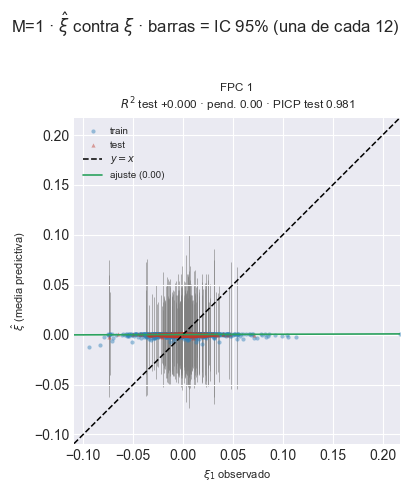

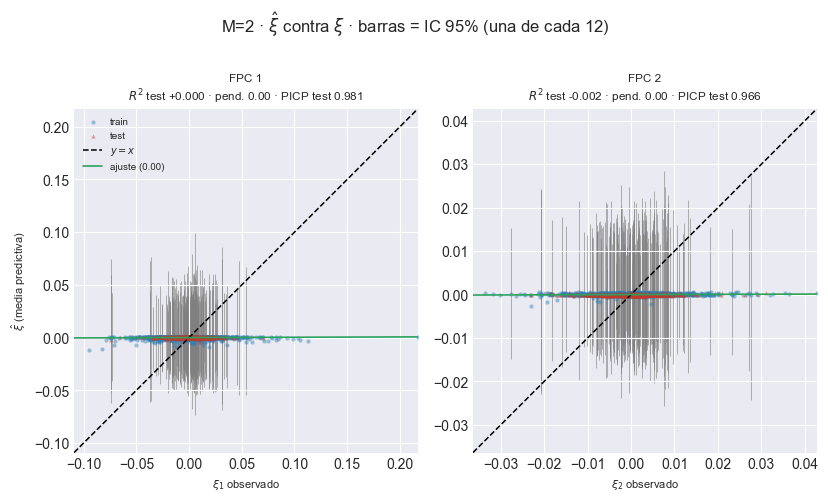

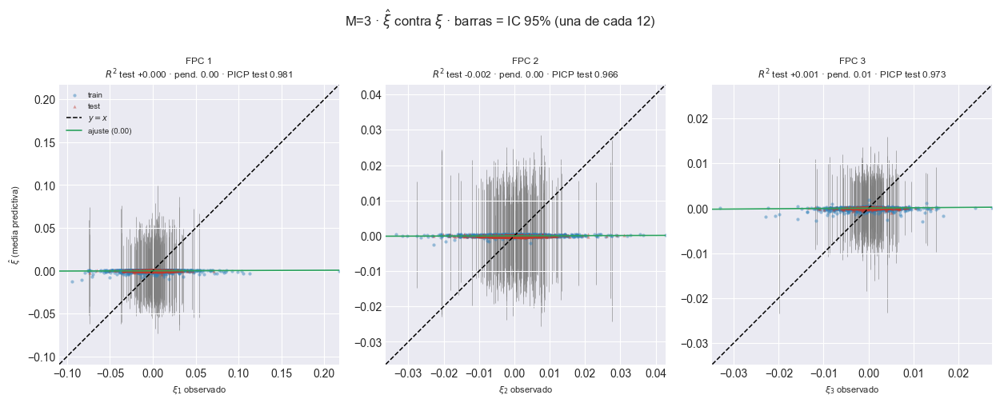

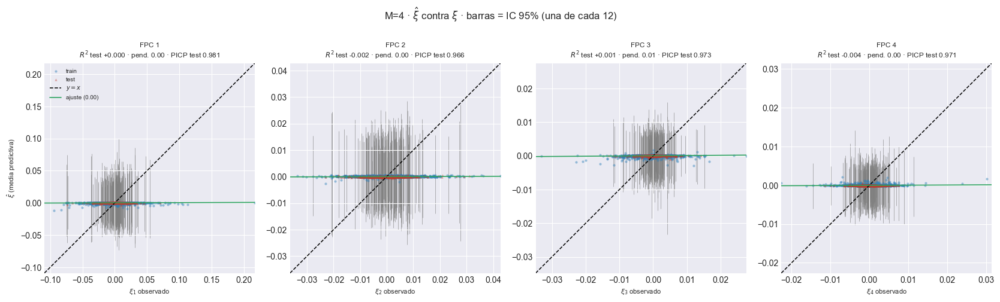

In [18]:
for M in M_OK:
    plot_scores_dispersion(EST[M], ORIG, DIS, M, CADA_BARRA,
                           save_path=EST[M]["paths"]["out_report"] / "94_scores_dispersion_vs_real.png")
    plt.show()